# Main text simulation study

This notebook implements the three main simulation subsections for the GRR manuscript. All table and plotting code is written directly in this notebook.

In [1]:

from __future__ import annotations

from pathlib import Path
from contextlib import contextmanager
import copy
import math
import os
import sys
import warnings

# Keep the executed notebook lightweight.  The Monte Carlo cells call genriesz
# thousands of times, and a few known non-inferential warnings can otherwise
# dominate the saved .ipynb file.  The warnings suppressed here are documented
# in the notebook comments and are still controlled by editable generator-shift
# and random-forest settings below.
warnings.filterwarnings("once")
# numpy 1.26 + Apple Accelerate BLAS emits spurious "... encountered in matmul"
# RuntimeWarnings for finite matrices (see doc/library_improvement_design.md sec 10.0);
# filter only these three so genuine non-matmul RuntimeWarnings stay visible.
warnings.filterwarnings("ignore", message=r"(?:divide by zero|overflow|invalid value) encountered in matmul$", category=RuntimeWarning)
warnings.filterwarnings("ignore", message=r"The generator's internal domain clip was active.*", category=UserWarning)
warnings.filterwarnings("ignore", message=r"ATT and DID Riesz representers.*", category=UserWarning)
warnings.filterwarnings("ignore", message=r"`sklearn\.utils\.parallel\.delayed`.*", category=UserWarning)
warnings.filterwarnings("ignore", module=r"sklearn\.utils\.parallel")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.special import expit

# Locate the repository root so the notebooks use the local source tree.
REPO_ROOT = Path.cwd().resolve()
for candidate in [REPO_ROOT, *REPO_ROOT.parents]:
    if (candidate / "src" / "genriesz").exists():
        REPO_ROOT = candidate
        break
else:
    raise RuntimeError("Run this notebook from inside the genriesz repository, or install genriesz first.")

SRC = REPO_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from genriesz import (
    BregmanGenerator,
    SquaredGenerator,
    UKLGenerator,
    BKLGenerator,
    BPGenerator,
    PolynomialBasis,
    TreatmentInteractionBasis,
    GaussianRKHSBasis,
    RBFRandomFourierBasis,
    grr_ate,
    grr_att,
)
from genriesz.basis import BaseBasis
from genriesz.functionals import ATEFunctional, ATTFunctional
from genriesz.glm import GRRGLM
try:
    from genriesz.sklearn_basis import RandomForestLeafBasis
except Exception:
    RandomForestLeafBasis = None

DATA_DIR = REPO_ROOT / "notebooks" / "experiments" / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 20260211
TREATMENT_INDEX = 0
ESTIMANDS = ("ATE", "ATT")
ESTIMATORS_ALL = ("ra", "rw", "arw", "tmle")
COMPATIBLE_LOSSES = [
    {"loss": "SQ", "omega": None, "label": "SQ"},
    {"loss": "UKL", "omega": None, "label": "UKL"},
    {"loss": "BKL", "omega": None, "label": "BKL"},
    {"loss": "BP", "omega": 0.5, "label": "BP(0.5)"},
]

# Branchwise KL-type generators require a shift C satisfying |alpha| > C.
# For ATE, inverse-propensity representers have |alpha| >= 1, so C=1 is natural.
# For ATT, the control branch e(z)/(pi*(1-e(z))) can be below one; using C=1
# forces the representer into the wrong domain and can create artificial weight explosions.
# The ATT shifts below keep the generator domain compatible with ATT while preserving
# the loss family comparison. Edit these constants directly if the DGP changes.
ATE_GENERATOR_SHIFT = 1.0
ATT_GENERATOR_SHIFT = 0.0
ATT_BKL_GENERATOR_SHIFT = 0.05

# Edit these dictionaries directly before plotting to change manuscript styling.
TABLE_CONFIG = {
    "float_format": "{:.4f}",
    "max_rows": 200,
    "caption_font_size": "12pt",
}
PLOT_CONFIG = {
    "figure_size": (9.0, 5.2),
    "figure_size_wide": (12.0, 5.2),
    "title_fontsize": 14,
    "axis_fontsize": 12,
    "tick_fontsize": 10,
    "legend_fontsize": 10,
    "line_width": 2.0,
    "marker_size": 5,
    "box_width": 0.70,
    "grid_alpha": 0.30,
    "dpi": 140,
    # Boxplots of squared error use a log scale by default because weak-overlap
    # designs can produce heavy right tails. Set to "linear" before plotting if desired.
    "squared_error_y_scale": "log",
    "squared_error_floor": 1e-12,
}
METHOD_LABELS = {
    "ra": "RA",
    "rw": "RW / IPW",
    "arw": "ARW / AIPW",
    "tmle": "TMLE",
    "SQ": "SQ-Riesz",
    "UKL": "UKL-Riesz",
    "BKL": "BKL-Riesz",
    "BP(0.5)": "BP-Riesz (ω=0.5)",
    "rkhs": "RKHS",
    "polynomial": "Polynomial",
    "rf": "Random forest leaves",
    "rff": "Random Fourier features",
    "matching": "Nearest-neighbor matching",
}
METHOD_COLORS = {
    "SQ": "#4C78A8",
    "UKL": "#F58518",
    "BKL": "#54A24B",
    "BP(0.5)": "#B279A2",
    "rkhs": "#4C78A8",
    "polynomial": "#F58518",
    "rf": "#54A24B",
    "rff": "#E45756",
    "matching": "#72B7B2",
}

# Random-forest leaf bases can trigger very large repeated scikit-learn parallel
# warnings in some local environments.  The default is serial fitting to keep the
# notebook file small and reproducible; change this to -1 if you want parallel
# fitting and your scikit-learn/joblib versions do not emit repeated warnings.
RF_N_JOBS = 1

@contextmanager
def suppress_known_experiment_warnings():
    """Suppress only high-volume warnings that otherwise bloat executed notebooks."""
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", message=r"ATT and DID Riesz representers.*", category=UserWarning)
        warnings.filterwarnings("ignore", message=r"`sklearn\.utils\.parallel\.delayed`.*", category=UserWarning)
        warnings.filterwarnings("ignore", module=r"sklearn\.utils\.parallel")
        yield

pd.options.display.max_rows = TABLE_CONFIG["max_rows"]


# --- Display-label normalization for rendered tables and figures --------------
# Abbreviations are upper-cased (RA, RW, ARW, TMLE, RKHS, NN); multi-word model
# names are title-cased (Random Forest, Random Fourier Features). Only rendered
# labels change: raw data keys are preserved so grouping/filtering/color logic
# keeps working.
import re as _re
DISPLAY_LABELS = {
    "ra": "RA", "rw": "RW", "arw": "ARW", "tmle": "TMLE",
    "rkhs": "RKHS", "polynomial": "Polynomial",
    "rf": "Random Forest", "rff": "Random Fourier Features",
    "matching": "Nearest-Neighbor Matching",
    "regressor": "Regressor", "covariate": "Covariate",
}
_LABEL_COLUMNS = ("estimator", "basis", "basis_mode", "loss", "loss_link_pair")


def label_of(value):
    """Display label for a raw key (unknown values returned unchanged)."""
    return DISPLAY_LABELS.get(str(value), str(value))


def prettify_method(text):
    """Map raw label tokens inside a composite string ('SQ (rkhs)' -> 'SQ (RKHS)')."""
    out = str(text)
    for _k, _v in DISPLAY_LABELS.items():
        out = _re.sub(r"(?<![A-Za-z0-9_])" + _re.escape(_k) + r"(?![A-Za-z0-9_])", _v, out)
    return out


def prettify_labels(df):
    """Copy of df with known label columns mapped to display labels."""
    out = df.copy()
    for _c in _LABEL_COLUMNS:
        if _c in out.columns:
            out[_c] = out[_c].map(label_of)
    return out


def display_table(df: pd.DataFrame, *, caption: str | None = None, digits: int = 4):
    """Notebook-local table display. Edit this cell to change formatting globally."""
    table = prettify_labels(df)
    numeric_cols = table.select_dtypes(include=[np.number]).columns
    table[numeric_cols] = table[numeric_cols].round(digits)
    styler = table.style.format(precision=digits)
    if caption is not None:
        styler = styler.set_caption(caption)
    display(styler)


def branch_treated(x: np.ndarray) -> int:
    return int(float(x[TREATMENT_INDEX]) >= 0.5)


def standardize_columns(Z: np.ndarray) -> np.ndarray:
    Z = np.asarray(Z, dtype=float)
    mean = Z.mean(axis=0)
    sd = Z.std(axis=0, ddof=0)
    sd = np.where(sd > 0, sd, 1.0)
    return (Z - mean) / sd


class ZOnlyBasis(BaseBasis):
    """Lift a covariate-only basis to X=[D,Z] by dropping the treatment column."""
    def __init__(self, base_basis, treatment_index: int = 0):
        self.base_basis = base_basis
        self.treatment_index = int(treatment_index)
        self._n_features = None

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        Z = np.delete(X, self.treatment_index, axis=1)
        self.base_basis.fit(Z, y=y)
        self._n_features = int(self.base_basis.n_features)
        return self

    def __call__(self, X):
        X = np.asarray(X, dtype=float)
        single = X.ndim == 1
        if single:
            X = X.reshape(1, -1)
        if self._n_features is None:
            self.fit(X)
        Z = np.delete(X, self.treatment_index, axis=1)
        Phi = np.asarray(self.base_basis(Z), dtype=float)
        return Phi[0] if single and Phi.ndim == 2 else Phi

    @property
    def n_features(self):
        if self._n_features is None:
            raise RuntimeError("ZOnlyBasis must be fit before n_features is available.")
        return int(self._n_features)

    def derivative(self, X, coordinate: int):
        X = np.asarray(X, dtype=float)
        single = X.ndim == 1
        if single:
            X = X.reshape(1, -1)
        if int(coordinate) == self.treatment_index:
            out = np.zeros((X.shape[0], self.n_features))
            return out[0] if single else out
        z_coordinate = int(coordinate) - 1 if int(coordinate) > self.treatment_index else int(coordinate)
        Z = np.delete(X, self.treatment_index, axis=1)
        out = np.asarray(self.base_basis.derivative(Z, z_coordinate), dtype=float)
        return out[0] if single and out.ndim == 2 else out


def make_base_basis(kind: str, *, seed: int = 0, n_features: int = 120, degree: int = 2, sigma: str | float = "auto"):
    kind = str(kind).lower()
    if kind == "polynomial":
        return PolynomialBasis(degree=degree, include_bias=True)
    if kind == "rkhs":
        return GaussianRKHSBasis(n_centers=n_features, sigma=sigma, include_bias=True, standardize=True, random_state=seed)
    if kind == "rff":
        return RBFRandomFourierBasis(n_features=n_features, sigma=sigma, include_bias=True, standardize=True, random_state=seed)
    if kind == "rf":
        if RandomForestLeafBasis is None:
            raise ImportError("RandomForestLeafBasis requires scikit-learn. Install the experiment requirements.")
        from sklearn.ensemble import RandomForestRegressor
        forest = RandomForestRegressor(
            n_estimators=max(50, n_features // 2),
            max_depth=4,
            min_samples_leaf=10,
            random_state=seed,
            n_jobs=int(globals().get("RF_N_JOBS", 1)),
        )
        return RandomForestLeafBasis(forest, include_bias=True, normalize=True)
    raise ValueError(f"Unknown basis kind: {kind}")


def make_basis(kind: str, *, mode: str = "regressor", seed: int = 0, n_features: int = 120, degree: int = 2, sigma: str | float = "auto"):
    base = make_base_basis(kind, seed=seed, n_features=n_features, degree=degree, sigma=sigma)
    if mode == "regressor":
        return TreatmentInteractionBasis(base_basis=base, treatment_index=TREATMENT_INDEX)
    if mode == "covariate":
        return ZOnlyBasis(base, treatment_index=TREATMENT_INDEX)
    raise ValueError("mode must be 'regressor' or 'covariate'")


# Finite-overlap guard for KL-type inverse links in the experiment notebooks.
# BKL, UKL, and BP links can approach the boundary of their domains in finite
# samples, especially for ATT and weak-overlap designs.  The cap below prevents
# numerical boundary explosions while keeping the rule visible and editable here.
EXPERIMENT_ALPHA_CAP = 50.0


class ExperimentUKLGenerator(UKLGenerator):
    def inv_grad(self, X, v):
        X = np.asarray(X, dtype=float)
        v = np.asarray(v, dtype=float).reshape(-1)
        s = np.empty(len(v), dtype=float)
        for i in range(len(v)):
            s[i] = 1.0 if int(branch_treated(X[i])) == 1 else -1.0
        if self.C > 0:
            upper = np.log(max(EXPERIMENT_ALPHA_CAP - self.C, 1e-8))
        else:
            upper = np.log(max(EXPERIMENT_ALPHA_CAP, 1e-8))
        z = np.clip(s * v, -60.0, upper)
        return s * (self.C + np.exp(z))

    modifies_estimand = True  # the EXPERIMENT_ALPHA_CAP clip modifies the estimand

    def domain_binding(self, X, v):
        # Match the np.clip in inv_grad so the reported clip-binding rate
        # reflects the real cap (the parent domain_binding does not track this).
        X = np.asarray(X, dtype=float)
        v = np.asarray(v, dtype=float).reshape(-1)
        s = np.array([1.0 if int(branch_treated(X[i])) == 1 else -1.0 for i in range(len(v))])
        if self.C > 0:
            upper = np.log(max(EXPERIMENT_ALPHA_CAP - self.C, 1e-8))
        else:
            upper = np.log(max(EXPERIMENT_ALPHA_CAP, 1e-8))
        z = s * v
        return (z < -60.0) | (z > upper)


class ExperimentBKLGenerator(BKLGenerator):
    def inv_grad(self, X, v):
        X = np.asarray(X, dtype=float)
        v = np.asarray(v, dtype=float).reshape(-1)
        s = np.empty(len(v), dtype=float)
        for i in range(len(v)):
            s[i] = 1.0 if int(branch_treated(X[i])) == 1 else -1.0
        if EXPERIMENT_ALPHA_CAP <= self.C:
            raise ValueError("EXPERIMENT_ALPHA_CAP must exceed C for BKL")
        upper = np.log((EXPERIMENT_ALPHA_CAP - self.C) / (EXPERIMENT_ALPHA_CAP + self.C))
        u = np.clip(s * v, -60.0, upper)
        t = np.exp(u)
        return s * self.C * (1.0 + t) / np.maximum(1.0 - t, 1e-12)

    modifies_estimand = True  # the EXPERIMENT_ALPHA_CAP clip modifies the estimand

    def domain_binding(self, X, v):
        # Match the np.clip in inv_grad so the reported clip-binding rate
        # reflects the real cap (the parent domain_binding does not track this).
        X = np.asarray(X, dtype=float)
        v = np.asarray(v, dtype=float).reshape(-1)
        s = np.array([1.0 if int(branch_treated(X[i])) == 1 else -1.0 for i in range(len(v))])
        upper = np.log((EXPERIMENT_ALPHA_CAP - self.C) / (EXPERIMENT_ALPHA_CAP + self.C))
        z = s * v
        return (z < -60.0) | (z > upper)


class ExperimentBPGenerator(BPGenerator):
    def inv_grad(self, X, v):
        X = np.asarray(X, dtype=float)
        v = np.asarray(v, dtype=float).reshape(-1)
        s = np.empty(len(v), dtype=float)
        for i in range(len(v)):
            s[i] = 1.0 if int(branch_treated(X[i])) == 1 else -1.0
        k = 1.0 + 1.0 / self.omega
        upper = np.power(max(EXPERIMENT_ALPHA_CAP - self.C, 1e-8), self.omega)
        t = np.clip(1.0 + s * v / k, 1e-6, upper)
        return s * (self.C + np.power(t, 1.0 / self.omega))

    modifies_estimand = True  # the EXPERIMENT_ALPHA_CAP clip modifies the estimand

    def domain_binding(self, X, v):
        # Match the np.clip in inv_grad so the reported clip-binding rate
        # reflects the real cap (the parent domain_binding does not track this).
        X = np.asarray(X, dtype=float)
        v = np.asarray(v, dtype=float).reshape(-1)
        s = np.array([1.0 if int(branch_treated(X[i])) == 1 else -1.0 for i in range(len(v))])
        k = 1.0 + 1.0 / self.omega
        upper = np.power(max(EXPERIMENT_ALPHA_CAP - self.C, 1e-8), self.omega)
        arg = 1.0 + s * v / k
        return (arg < 1e-6) | (arg > upper)


def make_compatible_generator(loss: str, *, omega: float | None = None, C: float = 1.0):
    loss = str(loss).upper()
    if loss == "SQ":
        return SquaredGenerator(C=0.0).as_generator()
    if loss == "UKL":
        return ExperimentUKLGenerator(C=C, branch_fn=branch_treated).as_generator()
    if loss == "BKL":
        return ExperimentBKLGenerator(C=C, branch_fn=branch_treated).as_generator()
    if loss == "BP":
        return ExperimentBPGenerator(C=C, omega=0.5 if omega is None else float(omega), branch_fn=branch_treated).as_generator()
    raise ValueError(loss)


def generator_shift_for_estimand(loss: str, estimand: str) -> float:
    """Choose the generator shift C for the target estimand.

    The choice is part of the experimental design, not a plotting trick.  ATE
    representers have branch magnitudes at least one under overlap, whereas ATT
    control-branch representers may be arbitrarily close to zero.  Using C=1 for
    ATT with UKL/BKL/BP is therefore domain-misspecified and was the main source
    of the previous artificial explosions.
    """
    loss_u = str(loss).upper()
    estimand_u = str(estimand).upper()
    if loss_u == "SQ":
        return 0.0
    if estimand_u == "ATE":
        return ATE_GENERATOR_SHIFT
    if estimand_u == "ATT" and loss_u == "BKL":
        return ATT_BKL_GENERATOR_SHIFT
    if estimand_u == "ATT":
        return ATT_GENERATOR_SHIFT
    raise ValueError(f"Unknown estimand: {estimand}")


def _signed_logit_link(X, v, *, C=1.0):
    X = np.asarray(X, dtype=float)
    v = np.asarray(v, dtype=float).reshape(-1)
    s = np.where(X[:, TREATMENT_INDEX] >= 0.5, 1.0, -1.0)
    z = np.clip(s * v, -60.0, 60.0)
    return s * (C + np.exp(z))


def _linear_link(X, v):
    return np.asarray(v, dtype=float).reshape(-1)


def make_incompatible_generator(pair_name: str):
    """Loss-link pairs intentionally not satisfying the GRR dual-linearity recipe."""
    pair_name = str(pair_name)
    if pair_name == "BKL loss + logit link":
        base = BKLGenerator(C=1.0, branch_fn=branch_treated).as_generator()
        return BregmanGenerator(g=base.g, grad=base.grad, grad2=base.grad2, inv_grad=lambda X, v: _signed_logit_link(X, v, C=1.0), name=pair_name)
    if pair_name == "SQ loss + logit link":
        base = SquaredGenerator(C=0.0).as_generator()
        return BregmanGenerator(g=base.g, grad=base.grad, grad2=base.grad2, inv_grad=lambda X, v: _signed_logit_link(X, v, C=1.0), name=pair_name)
    if pair_name == "UKL loss + linear link":
        base = UKLGenerator(C=1.0, branch_fn=branch_treated).as_generator()
        return BregmanGenerator(g=base.g, grad=base.grad, grad2=base.grad2, inv_grad=_linear_link, name=pair_name)
    raise ValueError(pair_name)


def make_simulation_data(dgp: str, *, n: int, seed: int):
    rng = np.random.default_rng(seed)
    if dgp == "DGP 1: smooth heterogeneous effects":
        d = 6
        Z = rng.normal(size=(n, d))
        logits = 0.6 * Z[:, 0] - 0.4 * Z[:, 1] + 0.25 * np.sin(Z[:, 2])
        noise_sd = 1.0
        tau = 1.0 + 0.45 * Z[:, 0] + 0.25 * np.sin(Z[:, 2])
        mu0 = 0.5 * Z[:, 0] + 0.4 * np.sin(Z[:, 1]) + 0.2 * Z[:, 2] ** 2
    elif dgp == "DGP 2: weak overlap nonlinear design":
        d = 8
        Z = rng.normal(size=(n, d))
        logits = 1.10 * Z[:, 0] - 0.90 * Z[:, 1] + 0.45 * np.sin(Z[:, 2]) + 0.25 * np.tanh(Z[:, 3] * Z[:, 4])
        noise_sd = 1.10
        tau = 1.0 + 0.30 * Z[:, 0] - 0.20 * Z[:, 1] + 0.20 * np.sin(Z[:, 3])
        mu0 = 0.35 * Z[:, 0] + 0.20 * np.tanh(Z[:, 1] ** 2) + 0.35 * np.sin(Z[:, 2])
    elif dgp == "DGP 3: high-dimensional sparse confounding":
        d = 20
        idx = np.arange(d)
        Sigma = 0.5 ** np.abs(idx[:, None] - idx[None, :])
        Z = rng.multivariate_normal(np.zeros(d), Sigma, size=n)
        logits = 0.75 * Z[:, 0] - 0.65 * Z[:, 1] + 0.45 * Z[:, 2] - 0.35 * Z[:, 3] + 0.25 * np.sin(Z[:, 4])
        noise_sd = 1.0
        tau = 1.0 + 0.30 * Z[:, 0] + 0.30 * np.sin(Z[:, 1]) + 0.20 * Z[:, 2] * Z[:, 3]
        mu0 = Z[:, :8] @ np.array([0.5, -0.4, 0.35, 0.25, -0.20, 0.15, 0.10, -0.10]) + 0.2 * np.sin(Z[:, 8])
    else:
        raise ValueError(dgp)
    e = np.clip(expit(logits), 0.05, 0.95)
    D = rng.binomial(1, e).astype(float)
    Y0 = mu0 + rng.normal(0.0, noise_sd, size=n)
    Y1 = mu0 + tau + rng.normal(0.0, noise_sd, size=n)
    Y = D * Y1 + (1.0 - D) * Y0
    X = np.column_stack([D, Z])
    return {
        "X": X, "Y": Y, "D": D, "Z": Z,
        "mu0": mu0, "mu1": mu0 + tau, "tau": tau, "e": e,
        "theta_ate": float(np.mean(tau)),
        "theta_att": float(np.mean(tau[D == 1])) if np.any(D == 1) else float(np.mean(tau)),
    }


def make_score_guided_data(*, n: int, seed: int, heterogeneous: bool = True):
    rng = np.random.default_rng(seed)
    Z = rng.normal(size=(n, 3))
    e = expit(0.5 * Z[:, 0] - 0.4 * Z[:, 1] + 0.2 * np.sin(Z[:, 2]))
    D = rng.binomial(1, e).astype(float)
    psi = np.column_stack([np.sin(Z[:, 0]), np.cos(Z[:, 1]), Z[:, 0] * Z[:, 2], Z[:, 1] ** 2, np.sin(Z[:, 2])])
    beta0 = np.array([0.4, -0.3, 0.2, 0.1, 0.2])
    betat = np.array([0.5, 0.2, -0.2, 0.15, 0.2]) if heterogeneous else np.zeros(5)
    mu0 = psi @ beta0
    tau = 1.0 + psi @ betat
    Y = mu0 + D * tau + rng.normal(scale=0.1, size=n)
    return {"X": np.column_stack([D, Z]), "Y": Y, "D": D, "Z": Z, "tau": tau, "theta_ate": float(np.mean(tau)), "theta_att": float(np.mean(tau[D == 1]))}


def make_kang_schafer_data(*, n: int, seed: int):
    rng = np.random.default_rng(seed)
    Z = rng.normal(size=(n, 4))
    logits = -Z[:, 0] + 0.5 * Z[:, 1] - 0.25 * Z[:, 2] - 0.1 * Z[:, 3]
    e = expit(logits)
    D = rng.binomial(1, e).astype(float)
    X1 = np.exp(Z[:, 0] / 2.0)
    X2 = Z[:, 1] / (1.0 + np.exp(Z[:, 0])) + 10.0
    X3 = (Z[:, 0] * Z[:, 2] / 25.0 + 0.6) ** 3
    X4 = (Z[:, 1] + Z[:, 3] + 20.0) ** 2
    features = standardize_columns(np.column_stack([X1, X2, X3, X4, X1**2, X2**2, X3**2, X4**2]))
    mu0 = 210.0 + 27.4 * Z[:, 0] + 13.7 * Z[:, 1] + 13.7 * Z[:, 2] + 13.7 * Z[:, 3]
    tau = np.ones(n)
    Y = mu0 + D * tau + rng.normal(scale=1.0, size=n)
    return {"X": np.column_stack([D, features]), "Y": Y, "D": D, "Z": features, "theta_ate": 1.0, "theta_att": 1.0, "e": e}


def make_kernel_gp_data(*, n: int, d: int, seed: int, outcome_kernel: str):
    rng = np.random.default_rng(seed)
    Z = rng.normal(size=(n, d))
    logits = 0.7 * Z[:, 0] - 0.4 * Z[:, 1] + 0.25 * np.sin(Z[:, 2])
    e = np.clip(expit(logits), 0.03, 0.97)
    D = rng.binomial(1, e).astype(float)
    if outcome_kernel == "polynomial":
        mu0 = 0.4 * Z[:, 0] + 0.35 * Z[:, 1] ** 2 - 0.25 * Z[:, 2] * Z[:, 3]
    elif outcome_kernel == "sinusoidal":
        mu0 = 0.5 * np.sin(Z[:, 0]) + 0.4 * np.cos(Z[:, 1]) + 0.25 * np.sin(Z[:, 2] * Z[:, 3])
    else:
        raise ValueError(outcome_kernel)
    tau = np.ones(n)
    Y = mu0 + D * tau + rng.normal(scale=1.0, size=n)
    return {"X": np.column_stack([D, Z]), "Y": Y, "D": D, "Z": Z, "tau": tau, "theta_ate": 1.0, "theta_att": 1.0}


def true_theta(data: dict, estimand: str):
    key = "theta_ate" if str(estimand).upper() == "ATE" else "theta_att"
    return None if key not in data else float(data[key])


def result_to_rows(res, *, label_info: dict, true_value: float | None):
    rows = []
    for estimator_key, est in res.estimates.items():
        row = dict(label_info)
        row.update({
            "estimator": estimator_key,
            "estimate": float(est.estimate),
            "se": float(est.se),
            "ci_low": float(est.ci_low),
            "ci_high": float(est.ci_high),
            "p_value": float(est.p_value),
            "status": "ok",
        })
        if true_value is not None:
            row["true_value"] = float(true_value)
            row["error"] = float(est.estimate - true_value)
            row["squared_error"] = float((est.estimate - true_value) ** 2)
            row["covered"] = bool(est.ci_low <= true_value <= est.ci_high)
        for k, v in res.diagnostics.items():
            if k == "love_plot":
                continue
            if isinstance(v, (int, float, bool, str)) or v is None:
                row[k] = v
        rows.append(row)
    return rows


def fit_one_grr(data: dict, *, estimand: str, loss_spec: dict, basis_kind: str, basis_mode: str = "regressor", outcome_basis_kind: str | None = None, outcome_basis_mode: str = "regressor", cross_fit: bool = True, lam: float = 1e-2, penalty: str = "l2", basis_features: int = 120, degree: int = 2, sigma: str | float = "auto", folds: int = 5, estimators=ESTIMATORS_ALL, max_iter: int = 500, random_state: int = 0):
    X = np.asarray(data["X"], dtype=float)
    Y = np.asarray(data["Y"], dtype=float)
    basis = make_basis(basis_kind, mode=basis_mode, seed=random_state, n_features=basis_features, degree=degree, sigma=sigma)
    gen = make_compatible_generator(loss_spec["loss"], omega=loss_spec.get("omega"), C=generator_shift_for_estimand(loss_spec["loss"], estimand))
    fn = grr_ate if estimand.upper() == "ATE" else grr_att
    need_outcome_model = any(str(e).lower() in {"ra", "arw", "tmle"} for e in estimators)
    outcome_basis = None
    if need_outcome_model:
        # The representer basis and the outcome basis are deliberately separated.
        # This prevents covariate-only balancing experiments from forcing the
        # outcome regression to ignore treatment-specific components, which created
        # degenerate zero-variance RA/RW comparisons in earlier notebooks.
        outcome_basis = make_basis(
            outcome_basis_kind or basis_kind,
            mode=outcome_basis_mode,
            seed=random_state + 7919,
            n_features=basis_features,
            degree=degree,
            sigma=sigma,
        )
    outcome_model_setting = "separate" if need_outcome_model else "none"
    label = dict(
        estimand=estimand.upper(), loss=loss_spec["label"], basis=basis_kind, basis_mode=basis_mode,
        outcome_basis=outcome_basis_kind or basis_kind, outcome_basis_mode=outcome_basis_mode,
        cross_fit=bool(cross_fit), lambda_riesz=float(lam), penalty=penalty,
    )
    try:
        with suppress_known_experiment_warnings():
            res = fn(
                X=X, Y=Y, basis=basis, generator=gen, treatment_index=TREATMENT_INDEX,
                cross_fit=bool(cross_fit), folds=int(folds), random_state=int(random_state),
                riesz_penalty=penalty, riesz_lam=float(lam),
                outcome_models=outcome_model_setting, outcome_basis=outcome_basis,
                outcome_penalty="l2", outcome_lam=1e-3,
                estimators=estimators, max_iter=max_iter, tol=1e-8,
            )
        return result_to_rows(res, label_info=label, true_value=true_theta(data, estimand))
    except Exception as exc:
        label.update({"estimator": "failed", "estimate": np.nan, "se": np.nan, "ci_low": np.nan, "ci_high": np.nan, "p_value": np.nan, "status": type(exc).__name__, "message": str(exc)[:250]})
        tv = true_theta(data, estimand)
        if tv is not None:
            label["true_value"] = tv
        return [label]


def fit_matching_ate(data: dict, *, rep: int, M: int = 1):
    """Nearest-neighbor matching baseline for ATE only.

    The current package matching methods return observation-level Riesz weights for
    ATE and do not provide a function-valued representer for ATT or TMLE.  We keep
    matching as an ATE-only baseline and do not fabricate an ATT analogue.
    """
    X = np.asarray(data["X"], dtype=float)
    Y = np.asarray(data["Y"], dtype=float)
    label = dict(
        estimand="ATE",
        loss="matching",
        basis="matching",
        basis_mode="matching",
        outcome_basis="none",
        outcome_basis_mode="none",
        cross_fit=False,
        lambda_riesz=np.nan,
        penalty="none",
        replication=int(rep),
    )
    try:
        basis = PolynomialBasis(degree=1, include_bias=True)
        res = grr_ate(
            X=X,
            Y=Y,
            basis=basis,
            treatment_index=TREATMENT_INDEX,
            riesz_method="nn_matching",
            M=int(M),
            cross_fit=False,
            outcome_models="none",
            estimators=("rw",),
        )
        return result_to_rows(res, label_info=label, true_value=true_theta(data, "ATE"))
    except Exception as exc:
        bad = dict(label)
        bad.update({"estimator": "failed", "estimate": np.nan, "se": np.nan, "ci_low": np.nan, "ci_high": np.nan, "p_value": np.nan, "status": type(exc).__name__, "message": str(exc)[:250]})
        tv = true_theta(data, "ATE")
        if tv is not None:
            bad["true_value"] = tv
        return [bad]


def fit_one_incompatible(data: dict, *, estimand: str, pair_name: str, cross_fit: bool = True, lam: float = 1e-2, basis_features: int = 120, folds: int = 5, max_iter: int = 500, random_state: int = 0):
    X = np.asarray(data["X"], dtype=float)
    Y = np.asarray(data["Y"], dtype=float)
    basis = make_basis("rkhs", mode="regressor", seed=random_state, n_features=basis_features, sigma="auto")
    gen = make_incompatible_generator(pair_name)
    fn = grr_ate if estimand.upper() == "ATE" else grr_att
    label = dict(estimand=estimand.upper(), loss_link_pair=pair_name, basis="rkhs", cross_fit=bool(cross_fit), lambda_riesz=float(lam), penalty="l2")
    try:
        with suppress_known_experiment_warnings():
            res = fn(
                X=X, Y=Y, basis=basis, generator=gen, treatment_index=TREATMENT_INDEX,
                cross_fit=bool(cross_fit), folds=int(folds), random_state=int(random_state),
                riesz_penalty="l2", riesz_lam=float(lam), outcome_penalty="l2", outcome_lam=1e-3,
                estimators=ESTIMATORS_ALL, max_iter=max_iter, tol=1e-8,
            )
        return result_to_rows(res, label_info=label, true_value=true_theta(data, estimand))
    except Exception as exc:
        label.update({"estimator": "failed", "estimate": np.nan, "se": np.nan, "ci_low": np.nan, "ci_high": np.nan, "p_value": np.nan, "status": type(exc).__name__, "message": str(exc)[:250]})
        tv = true_theta(data, estimand)
        if tv is not None:
            label["true_value"] = tv
        return [label]


def summarize_estimates(df: pd.DataFrame, group_cols: list[str]):
    ok = df[(df["status"] == "ok") & (df["estimator"] != "failed")].copy()
    if ok.empty:
        return ok
    agg = {"estimate": ["mean", "std"], "se": "mean"}
    if "squared_error" in ok.columns:
        agg["squared_error"] = ["mean"]
    for c in ["alpha_abs_p95", "alpha_abs_max", "max_abs_smd_weighted", "ess_treated", "ess_control"]:
        if c in ok.columns:
            agg[c] = "mean"
    # Surface the clip-binding diagnostic so suppressing its per-run warning
    # does not hide a modified (clipped) estimand (never silent-clip).
    if "riesz_clip_binding_rate_max" in ok.columns:
        agg["riesz_clip_binding_rate_max"] = ["mean", "max"]
    if "riesz_modifies_estimand" in ok.columns:
        agg["riesz_modifies_estimand"] = "mean"
    out = ok.groupby(group_cols, dropna=False).agg(agg)
    out.columns = ["_".join([str(x) for x in col if x != ""]).strip("_") for col in out.columns.to_flat_index()]
    out = out.reset_index()
    if "squared_error_mean" in out.columns:
        out = out.rename(columns={"squared_error_mean": "mse"})
        out["rmse"] = np.sqrt(out["mse"])
    if "covered" in ok.columns:
        coverage = ok.groupby(group_cols, dropna=False)["covered"].mean().rename("coverage").reset_index()
        out = out.merge(coverage, on=group_cols, how="left")
    return out


def load_ihdp_replication(replication: int, *, data_dir: Path = DATA_DIR / "ihdp"):
    train_path = data_dir / "ihdp_npci_1-100.train.npz"
    test_path = data_dir / "ihdp_npci_1-100.test.npz"
    if not train_path.exists() or not test_path.exists():
        raise FileNotFoundError(
            "IHDP npci files were not found. Place ihdp_npci_1-100.train.npz and ihdp_npci_1-100.test.npz "
            f"under {data_dir}. This notebook does not use synthetic fallback data."
        )
    train = np.load(train_path)
    test = np.load(test_path)
    j = int(replication) - 1
    n_reps = train["x"].shape[2]
    if j < 0 or j >= n_reps:
        raise ValueError(f"replication must be between 1 and {n_reps}")
    Xcov = np.vstack([train["x"][:, :, j], test["x"][:, :, j]])
    D = np.concatenate([train["t"][:, j], test["t"][:, j]]).astype(float)
    Y = np.concatenate([train["yf"][:, j], test["yf"][:, j]]).astype(float)
    mu1 = np.concatenate([train["mu1"][:, j], test["mu1"][:, j]]).astype(float)
    mu0 = np.concatenate([train["mu0"][:, j], test["mu0"][:, j]]).astype(float)
    tau = mu1 - mu0
    return {
        "X": np.column_stack([D, Xcov]), "Y": Y, "D": D, "Z": Xcov,
        "mu1": mu1, "mu0": mu0, "tau": tau,
        "theta_ate": float(np.mean(tau)),
        "theta_att": float(np.mean(tau[D == 1])) if np.any(D == 1) else float(np.mean(tau)),
        "replication": int(replication),
        "source": str(train_path.name),
    }


def load_lalonde(*, data_dir: Path = DATA_DIR / "lalonde"):
    data_dir.mkdir(parents=True, exist_ok=True)
    csv_path = data_dir / "lalonde.csv"
    url = "https://raw.githubusercontent.com/robjellis/lalonde/master/lalonde_data.csv"
    if not csv_path.exists():
        # Formal experiment: download the public MatchIt/Rdatasets Lalonde file. No fallback data are generated.
        df = pd.read_csv(url)
        df.to_csv(csv_path, index=False)
    else:
        df = pd.read_csv(csv_path)
    for id_col in ["rownames", "ID"]:
        if id_col in df.columns:
            df = df.drop(columns=[id_col])
    if "race" in df.columns:
        race_dummies = pd.get_dummies(df["race"], prefix="race", drop_first=False, dtype=float)
        df = pd.concat([df.drop(columns=["race"]), race_dummies], axis=1)
    required = ["treat", "age", "educ", "married", "nodegree", "re74", "re75", "re78"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Lalonde file is missing required columns: {missing}")
    covariates = [c for c in df.columns if c not in {"treat", "re78"}]
    D = df["treat"].astype(float).to_numpy()
    Y = df["re78"].astype(float).to_numpy()
    Z = df[covariates].astype(float).to_numpy()
    Z = standardize_columns(Z)
    return {"X": np.column_stack([D, Z]), "Y": Y, "D": D, "Z": Z, "covariate_names": covariates, "source": str(csv_path)}



# ---------------------------------------------------------------------------
# Manual incompatible loss-link estimators for the main simulation subsection.
# These are intentionally implemented inside the notebooks, not in a helper file.
# ---------------------------------------------------------------------------

def _weighted_mean(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    denom = np.sum(weights)
    if denom <= 0 or not np.isfinite(denom):
        return np.nan
    return float(np.sum(weights * values) / denom)


def _max_weighted_smd(Z, D, weights):
    Z = np.asarray(Z, dtype=float)
    D = np.asarray(D, dtype=float)
    weights = np.asarray(weights, dtype=float)
    out = []
    for j in range(Z.shape[1]):
        z = Z[:, j]
        pooled = math.sqrt(0.5 * (np.var(z[D == 1]) + np.var(z[D == 0]))) if np.any(D == 1) and np.any(D == 0) else np.nan
        if not np.isfinite(pooled) or pooled == 0:
            continue
        mu1 = _weighted_mean(z[D == 1], weights[D == 1])
        mu0 = _weighted_mean(z[D == 0], weights[D == 0])
        if np.isfinite(mu1) and np.isfinite(mu0):
            out.append(abs((mu1 - mu0) / pooled))
    return float(np.max(out)) if out else np.nan


def _fit_propensity_index(Phi, D, *, pair_name: str, lam: float):
    D = np.asarray(D, dtype=float)
    if pair_name == "BKL loss + logit link":
        from sklearn.linear_model import LogisticRegression
        Cval = 1.0 / max(float(lam), 1e-8)
        model = LogisticRegression(C=Cval, fit_intercept=False, solver="lbfgs", max_iter=2000)
        model.fit(Phi, D.astype(int))
        return np.asarray(model.coef_).reshape(-1)
    if pair_name == "SQ loss + logit link":
        from scipy import optimize
        beta0 = np.zeros(Phi.shape[1])
        def obj(beta):
            p = expit(Phi @ beta)
            return float(np.mean((D - p) ** 2) + 0.5 * float(lam) * np.sum(beta * beta))
        def grad(beta):
            p = expit(Phi @ beta)
            return (2.0 * ((p - D) * p * (1.0 - p))[:, None] * Phi).mean(axis=0) + float(lam) * beta
        res = optimize.minimize(obj, beta0, jac=grad, method="L-BFGS-B", options={"maxiter": 2000, "ftol": 1e-10})
        return np.asarray(res.x, dtype=float)
    raise ValueError(pair_name)


def _fit_linear_ukl_representer(X_train, estimand: str, *, lam: float, n_features: int, random_state: int):
    from scipy import optimize
    functional = ATEFunctional(treatment_index=TREATMENT_INDEX) if estimand.upper() == "ATE" else ATTFunctional(treatment_index=TREATMENT_INDEX, pi=float(np.mean(X_train[:, TREATMENT_INDEX])))
    basis = make_basis("rkhs", mode="regressor", seed=random_state, n_features=n_features, sigma="auto")
    basis.fit(X_train)
    Phi = np.asarray(basis(X_train), dtype=float)
    M_dummy = np.asarray(functional.m_basis_matrix(X_train, basis), dtype=float)
    eps = 1e-4
    def _safe_g(X_, alpha_):
        alpha_ = np.asarray(alpha_, dtype=float).reshape(-1)
        r = np.sqrt(alpha_ * alpha_ + eps * eps)
        return r * np.log(r) - r
    def _safe_grad(X_, alpha_):
        alpha_ = np.asarray(alpha_, dtype=float).reshape(-1)
        r = np.sqrt(alpha_ * alpha_ + eps * eps)
        return (alpha_ / r) * np.log(r)
    def _safe_grad2(X_, alpha_):
        alpha_ = np.asarray(alpha_, dtype=float).reshape(-1)
        r = np.sqrt(alpha_ * alpha_ + eps * eps)
        out = (alpha_ * alpha_ + eps * eps * np.log(r)) / np.maximum(r ** 3, eps ** 3)
        return np.maximum(out, 1e-3)
    gen = BregmanGenerator(g=_safe_g, grad=_safe_grad, grad2=_safe_grad2, inv_grad=_linear_link, name="safe UKL loss + linear link")
    X1 = X_train.copy(); X1[:, TREATMENT_INDEX] = 1.0
    X0 = X_train.copy(); X0[:, TREATMENT_INDEX] = 0.0
    Phi1 = np.asarray(basis(X1), dtype=float)
    Phi0 = np.asarray(basis(X0), dtype=float)
    D = X_train[:, TREATMENT_INDEX]
    pi = max(float(np.mean(D)), 1e-8)
    # Start from the squared-loss Riesz solution.  Starting at exactly zero makes
    # the linear-link UKL experiment numerically degenerate because the smoothed
    # absolute-value UKL gradient is nearly symmetric at the origin.
    ridge_matrix = (Phi.T @ Phi) / max(len(Phi), 1) + max(float(lam), 1e-6) * np.eye(Phi.shape[1])
    ridge_rhs = np.nanmean(M_dummy, axis=0)
    try:
        beta0 = np.linalg.solve(ridge_matrix, ridge_rhs)
    except np.linalg.LinAlgError:
        beta0 = np.linalg.pinv(ridge_matrix) @ ridge_rhs
    beta0 = np.asarray(beta0, dtype=float)
    def objective(beta):
        alpha_obs = Phi @ beta
        v_obs = gen.grad(X_train, alpha_obs)
        g_obs = gen.g(X_train, alpha_obs)
        alpha1 = Phi1 @ beta
        alpha0 = Phi0 @ beta
        v1 = gen.grad(X1, alpha1)
        v0 = gen.grad(X0, alpha0)
        if estimand.upper() == "ATE":
            m_v = v1 - v0
        else:
            m_v = (D / pi) * (v1 - v0)
        return float(np.mean(-g_obs + v_obs * alpha_obs - m_v) + 0.5 * float(lam) * np.sum(beta * beta))
    def gradient(beta):
        alpha_obs = Phi @ beta
        g2_obs = gen.grad2(X_train, alpha_obs)
        term_obs = g2_obs[:, None] * alpha_obs[:, None] * Phi
        alpha1 = Phi1 @ beta
        alpha0 = Phi0 @ beta
        g2_1 = gen.grad2(X1, alpha1)
        g2_0 = gen.grad2(X0, alpha0)
        if estimand.upper() == "ATE":
            m_grad = g2_1[:, None] * Phi1 - g2_0[:, None] * Phi0
        else:
            m_grad = (D[:, None] / pi) * (g2_1[:, None] * Phi1 - g2_0[:, None] * Phi0)
        return np.mean(term_obs - m_grad, axis=0) + float(lam) * beta
    res = optimize.minimize(objective, beta0, jac=gradient, method="L-BFGS-B", options={"maxiter": 2000, "ftol": 1e-10})
    return basis, np.asarray(res.x, dtype=float), str(res.message)


def _ridge_outcome_fit(X_train, Y_train, *, n_features: int, random_state: int):
    from sklearn.linear_model import Ridge
    basis = make_basis("rkhs", mode="regressor", seed=random_state, n_features=n_features, sigma="auto")
    basis.fit(X_train, y=Y_train)
    Phi = np.asarray(basis(X_train), dtype=float)
    model = Ridge(alpha=1e-3, fit_intercept=False)
    model.fit(Phi, Y_train)
    return basis, model


def _normal_ci_row(label_info, estimator_key, theta, psi, true_value, diagnostics):
    psi = np.asarray(psi, dtype=float)
    n = len(psi)
    se = float(np.sqrt(np.nanvar(psi, ddof=1) / n)) if n > 1 else np.nan
    ci_low = float(theta - 1.959963984540054 * se) if np.isfinite(se) else np.nan
    ci_high = float(theta + 1.959963984540054 * se) if np.isfinite(se) else np.nan
    row = dict(label_info)
    row.update({"estimator": estimator_key, "estimate": float(theta), "se": se, "ci_low": ci_low, "ci_high": ci_high, "p_value": np.nan, "status": "ok"})
    if true_value is not None:
        row["true_value"] = float(true_value)
        row["error"] = float(theta - true_value)
        row["squared_error"] = float((theta - true_value) ** 2)
        row["covered"] = bool(ci_low <= true_value <= ci_high) if np.isfinite(ci_low) and np.isfinite(ci_high) else False
    row.update(diagnostics)
    return row


def fit_one_incompatible(data: dict, *, estimand: str, pair_name: str, cross_fit: bool = True, lam: float = 1e-2, basis_features: int = 120, folds: int = 5, max_iter: int = 500, random_state: int = 0):
    """Cross-fitted incompatible loss-link experiment with RKHS features.

    BKL/logit and SQ/logit fit a propensity-index model. UKL/linear directly fits
    a linear representer under a UKL objective. All steps are notebook-local so the
    estimator definitions can be modified here.
    """
    from sklearn.model_selection import KFold
    X = np.asarray(data["X"], dtype=float)
    Y = np.asarray(data["Y"], dtype=float)
    D = X[:, TREATMENT_INDEX].astype(float)
    Z = np.delete(X, TREATMENT_INDEX, axis=1)
    n = len(Y)
    true_value = true_theta(data, estimand)
    label = {"estimand": estimand.upper(), "loss_link_pair": pair_name, "basis": "rkhs", "cross_fit": bool(cross_fit), "lambda_riesz": float(lam), "penalty": "l2"}
    alpha = np.zeros(n)
    alpha1 = np.zeros(n)
    alpha0 = np.zeros(n)
    mu_obs = np.zeros(n)
    mu1 = np.zeros(n)
    mu0 = np.zeros(n)
    if cross_fit:
        splitter = KFold(n_splits=int(folds), shuffle=True, random_state=random_state)
        splits = list(splitter.split(X))
    else:
        idx = np.arange(n)
        splits = [(idx, idx)]
    fit_messages = []
    try:
        for fold_id, (train_idx, test_idx) in enumerate(splits):
            X_tr, Y_tr = X[train_idx], Y[train_idx]
            D_tr = D[train_idx]
            Z_tr = Z[train_idx]
            X_te = X[test_idx]
            Z_te = Z[test_idx]
            pi_train = max(float(np.mean(D_tr)), 1e-8)
            if pair_name in {"BKL loss + logit link", "SQ loss + logit link"}:
                prop_basis = make_base_basis("rkhs", seed=random_state + fold_id, n_features=basis_features, sigma="auto")
                prop_basis.fit(Z_tr, y=D_tr)
                Phi_tr = np.asarray(prop_basis(Z_tr), dtype=float)
                beta = _fit_propensity_index(Phi_tr, D_tr, pair_name=pair_name, lam=lam)
                def ehat(Znew):
                    return np.clip(expit(np.asarray(prop_basis(Znew), dtype=float) @ beta), 0.02, 0.98)
                e_obs = ehat(Z_te)
                if estimand.upper() == "ATE":
                    alpha[test_idx] = X_te[:, TREATMENT_INDEX] / e_obs - (1.0 - X_te[:, TREATMENT_INDEX]) / (1.0 - e_obs)
                    alpha1[test_idx] = 1.0 / e_obs
                    alpha0[test_idx] = -1.0 / (1.0 - e_obs)
                else:
                    alpha[test_idx] = X_te[:, TREATMENT_INDEX] / pi_train - (1.0 - X_te[:, TREATMENT_INDEX]) * e_obs / (pi_train * (1.0 - e_obs))
                    alpha1[test_idx] = 1.0 / pi_train
                    alpha0[test_idx] = -e_obs / (pi_train * (1.0 - e_obs))
            elif pair_name == "UKL loss + linear link":
                r_basis, beta, msg = _fit_linear_ukl_representer(X_tr, estimand, lam=lam, n_features=basis_features, random_state=random_state + fold_id)
                fit_messages.append(msg)
                alpha[test_idx] = np.asarray(r_basis(X_te), dtype=float) @ beta
                X1 = X_te.copy(); X1[:, TREATMENT_INDEX] = 1.0
                X0 = X_te.copy(); X0[:, TREATMENT_INDEX] = 0.0
                alpha1[test_idx] = np.asarray(r_basis(X1), dtype=float) @ beta
                alpha0[test_idx] = np.asarray(r_basis(X0), dtype=float) @ beta
            else:
                raise ValueError(pair_name)
            out_basis, out_model = _ridge_outcome_fit(X_tr, Y_tr, n_features=basis_features, random_state=random_state + 1000 + fold_id)
            mu_obs[test_idx] = out_model.predict(np.asarray(out_basis(X_te), dtype=float))
            X1 = X_te.copy(); X1[:, TREATMENT_INDEX] = 1.0
            X0 = X_te.copy(); X0[:, TREATMENT_INDEX] = 0.0
            mu1[test_idx] = out_model.predict(np.asarray(out_basis(X1), dtype=float))
            mu0[test_idx] = out_model.predict(np.asarray(out_basis(X0), dtype=float))
        pi = max(float(np.mean(D)), 1e-8)
        if estimand.upper() == "ATE":
            m_mu = mu1 - mu0
            m_mu_star_weight = None
        else:
            m_mu = (D / pi) * (mu1 - mu0)
        theta_ra = float(np.mean(m_mu))
        theta_rw = float(np.mean(alpha * Y))
        theta_arw = float(np.mean(m_mu + alpha * (Y - mu_obs)))
        eps = float(np.sum(alpha * (Y - mu_obs)) / max(np.sum(alpha * alpha), 1e-12))
        mu_obs_star = mu_obs + eps * alpha
        mu1_star = mu1 + eps * alpha1
        mu0_star = mu0 + eps * alpha0
        if estimand.upper() == "ATE":
            m_mu_star = mu1_star - mu0_star
        else:
            m_mu_star = (D / pi) * (mu1_star - mu0_star)
        theta_tmle = float(np.mean(m_mu_star))
        diagnostics = {
            "alpha_abs_mean": float(np.mean(np.abs(alpha))),
            "alpha_abs_p95": float(np.percentile(np.abs(alpha), 95)),
            "alpha_abs_max": float(np.max(np.abs(alpha))),
            "max_abs_smd_weighted": _max_weighted_smd(Z, D, np.abs(alpha)),
            "ess_treated": float((np.sum(np.abs(alpha[D == 1])) ** 2) / max(np.sum(np.abs(alpha[D == 1]) ** 2), 1e-12)),
            "ess_control": float((np.sum(np.abs(alpha[D == 0])) ** 2) / max(np.sum(np.abs(alpha[D == 0]) ** 2), 1e-12)),
        }
        return [
            _normal_ci_row(label, "ra", theta_ra, m_mu - theta_ra, true_value, diagnostics),
            _normal_ci_row(label, "rw", theta_rw, alpha * Y - theta_rw, true_value, diagnostics),
            _normal_ci_row(label, "arw", theta_arw, m_mu + alpha * (Y - mu_obs) - theta_arw, true_value, diagnostics),
            _normal_ci_row(label, "tmle", theta_tmle, m_mu_star + alpha * (Y - mu_obs_star) - theta_tmle, true_value, diagnostics),
        ]
    except Exception as exc:
        bad = dict(label)
        bad.update({"estimator": "failed", "estimate": np.nan, "se": np.nan, "ci_low": np.nan, "ci_high": np.nan, "p_value": np.nan, "status": type(exc).__name__, "message": str(exc)[:250]})
        if true_value is not None:
            bad["true_value"] = true_value
        return [bad]


In [2]:
# Publication-scale settings. Edit here if the manuscript grid changes.
N_REPLICATIONS = 100
SAMPLE_SIZE = 1200
DGP_NAMES = [
    "DGP 1: smooth heterogeneous effects",
    "DGP 2: weak overlap nonlinear design",
    "DGP 3: high-dimensional sparse confounding",
]
BASIS_KINDS_MAIN = ["rkhs", "polynomial", "rf"]
RIEZ_FEATURES = 120
POLYNOMIAL_DEGREE = 2
FOLDS = 5
RIEZ_LAMBDA_MAIN = 3e-1
OUTCOME_LAMBDA = 1e-3
RF_N_JOBS = 1  # Change to -1 for parallel RF fitting only if your environment does not emit repeated joblib warnings.

settings_table = pd.DataFrame([{
    "N_REPLICATIONS": N_REPLICATIONS,
    "SAMPLE_SIZE": SAMPLE_SIZE,
    "N_DGPS": len(DGP_NAMES),
    "BASIS_KINDS": ", ".join(BASIS_KINDS_MAIN),
    "RIEZ_FEATURES": RIEZ_FEATURES,
    "FOLDS": FOLDS,
    "RF_N_JOBS": RF_N_JOBS,
}])
display_table(settings_table, caption="Main simulation settings")


,N_REPLICATIONS,SAMPLE_SIZE,N_DGPS,BASIS_KINDS,RIEZ_FEATURES,FOLDS,RF_N_JOBS
0,100,1200,3,"rkhs, polynomial, rf",120,5,1


## 1. Compatible regressor-balancing loss-link pairs

Each loss uses its generator-induced compatible link. The balancing dictionary is treatment-interaction basis functions of the full regressor `X=(D,Z)`. This directly targets the score-relevant regression error for ATE under treatment-effect heterogeneity.

In [3]:
# Direct Monte Carlo loop. This cell is intentionally written in the notebook so the experimental grid can be edited here.
rows = []
for dgp_name in DGP_NAMES:
    for rep in range(N_REPLICATIONS):
        data = make_simulation_data(dgp_name, n=SAMPLE_SIZE, seed=100000 + 1009 * rep)
        for basis_kind in BASIS_KINDS_MAIN:
            for loss_spec in COMPATIBLE_LOSSES:
                for estimand in ESTIMANDS:
                    fit_rows = fit_one_grr(
                        data,
                        estimand=estimand,
                        loss_spec=loss_spec,
                        basis_kind=basis_kind,
                        basis_mode="regressor",
                        cross_fit=True,
                        lam=RIEZ_LAMBDA_MAIN,
                        basis_features=RIEZ_FEATURES,
                        degree=POLYNOMIAL_DEGREE,
                        folds=FOLDS,
                        estimators=ESTIMATORS_ALL,
                        random_state=rep,
                    )
                    for row in fit_rows:
                        row["dgp"] = dgp_name
                        row["replication"] = rep
                    rows.extend(fit_rows)
main_compatible = pd.DataFrame(rows)
summary_compatible = summarize_estimates(main_compatible, ["dgp", "estimand", "basis", "loss", "estimator"])

# Display ATE and ATT in separate tables. Do not place them side by side.
for estimand_name in ESTIMANDS:
    table_df = summary_compatible[summary_compatible["estimand"] == estimand_name].copy()
    if table_df.empty:
        print(f"No rows for {estimand_name}.")
        continue
    table_df = table_df.drop(columns=["estimand"])
    table_df = table_df.sort_values(["dgp", "basis", "loss", "estimator"])
    display_table(table_df, caption=f"Main simulation compatible loss-link pairs: {estimand_name}")


,dgp,basis,loss,estimator,estimate_mean,estimate_std,se_mean,mse,alpha_abs_p95_mean,alpha_abs_max_mean,max_abs_smd_weighted_mean,ess_treated_mean,ess_control_mean,rmse,coverage
0,DGP 1: smooth heterogeneous effects,polynomial,BKL,arw,1.0149,0.0763,0.0885,0.0064,4.3023,32.4197,0.0643,438.2128,438.4383,0.0800,0.9900
1,DGP 1: smooth heterogeneous effects,polynomial,BKL,ra,1.0097,0.0624,0.0174,0.0041,4.3023,32.4197,0.0643,438.2128,438.4383,0.0641,0.4300
2,DGP 1: smooth heterogeneous effects,polynomial,BKL,rw,1.2545,0.0945,0.1146,0.0752,4.3023,32.4197,0.0643,438.2128,438.4383,0.2742,0.3500
3,DGP 1: smooth heterogeneous effects,polynomial,BKL,tmle,1.0129,0.0661,0.0862,0.0048,4.3023,32.4197,0.0643,438.2128,438.4383,0.0692,0.9900
4,DGP 1: smooth heterogeneous effects,polynomial,BP(0.5),arw,1.0091,0.0641,0.0633,0.0043,2.8367,5.2851,0.2896,573.2907,574.6318,0.0659,0.9500
5,DGP 1: smooth heterogeneous effects,polynomial,BP(0.5),ra,1.0097,0.0624,0.0174,0.0041,2.8367,5.2851,0.2896,573.2907,574.6318,0.0641,0.4300
6,DGP 1: smooth heterogeneous effects,polynomial,BP(0.5),rw,1.1874,0.0574,0.0883,0.0392,2.8367,5.2851,0.2896,573.2907,574.6318,0.1980,0.3700
7,DGP 1: smooth heterogeneous effects,polynomial,BP(0.5),tmle,1.0091,0.0641,0.0633,0.0043,2.8367,5.2851,0.2896,573.2907,574.6318,0.0659,0.9500
8,DGP 1: smooth heterogeneous effects,polynomial,SQ,arw,1.0082,0.0640,0.0516,0.0043,2.7865,5.3287,0.4185,494.7090,496.0140,0.0657,0.8600
9,DGP 1: smooth heterogeneous effects,polynomial,SQ,ra,1.0097,0.0624,0.0174,0.0041,2.7865,5.3287,0.4185,494.7090,496.0140,0.0641,0.4300


,dgp,basis,loss,estimator,estimate_mean,estimate_std,se_mean,mse,alpha_abs_p95_mean,alpha_abs_max_mean,max_abs_smd_weighted_mean,ess_treated_mean,ess_control_mean,rmse,coverage
48,DGP 1: smooth heterogeneous effects,polynomial,BKL,arw,1.1188,0.1463,0.1811,0.0211,4.2245,50.0000,0.2605,598.8214,94.7167,0.1454,1.0000
49,DGP 1: smooth heterogeneous effects,polynomial,BKL,ra,1.1423,0.0683,0.0409,0.0050,4.2245,50.0000,0.2605,598.8214,94.7167,0.0708,0.7300
50,DGP 1: smooth heterogeneous effects,polynomial,BKL,rw,0.8371,0.1986,0.2218,0.1273,4.2245,50.0000,0.2605,598.8214,94.7167,0.3567,0.7800
51,DGP 1: smooth heterogeneous effects,polynomial,BKL,tmle,1.1360,0.0703,0.1760,0.0051,4.2245,50.0000,0.2605,598.8214,94.7167,0.0715,1.0000
52,DGP 1: smooth heterogeneous effects,polynomial,BP(0.5),arw,1.1383,0.0705,0.0729,0.0053,3.1897,10.4857,0.2399,579.4516,441.2985,0.0730,0.9400
53,DGP 1: smooth heterogeneous effects,polynomial,BP(0.5),ra,1.1423,0.0683,0.0409,0.0050,3.1897,10.4857,0.2399,579.4516,441.2985,0.0708,0.7300
54,DGP 1: smooth heterogeneous effects,polynomial,BP(0.5),rw,1.0896,0.0582,0.0922,0.0050,3.1897,10.4857,0.2399,579.4516,441.2985,0.0708,1.0000
55,DGP 1: smooth heterogeneous effects,polynomial,BP(0.5),tmle,1.1382,0.0706,0.0726,0.0053,3.1897,10.4857,0.2399,579.4516,441.2985,0.0731,0.9400
56,DGP 1: smooth heterogeneous effects,polynomial,SQ,arw,1.1410,0.0696,0.0644,0.0052,2.9180,6.2821,0.3461,513.8070,443.5549,0.0722,0.9100
57,DGP 1: smooth heterogeneous effects,polynomial,SQ,ra,1.1423,0.0683,0.0409,0.0050,2.9180,6.2821,0.3461,513.8070,443.5549,0.0708,0.7300


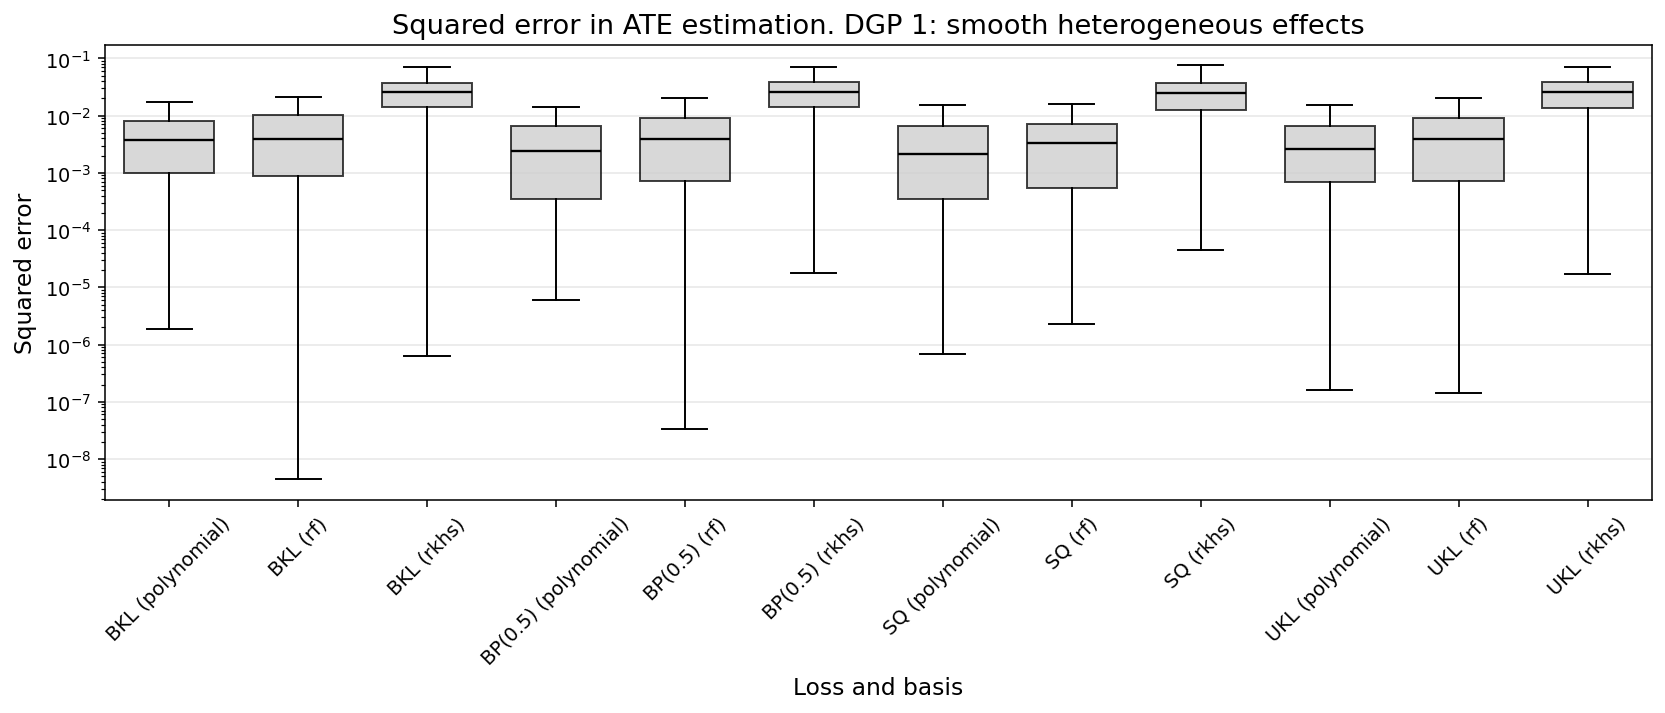

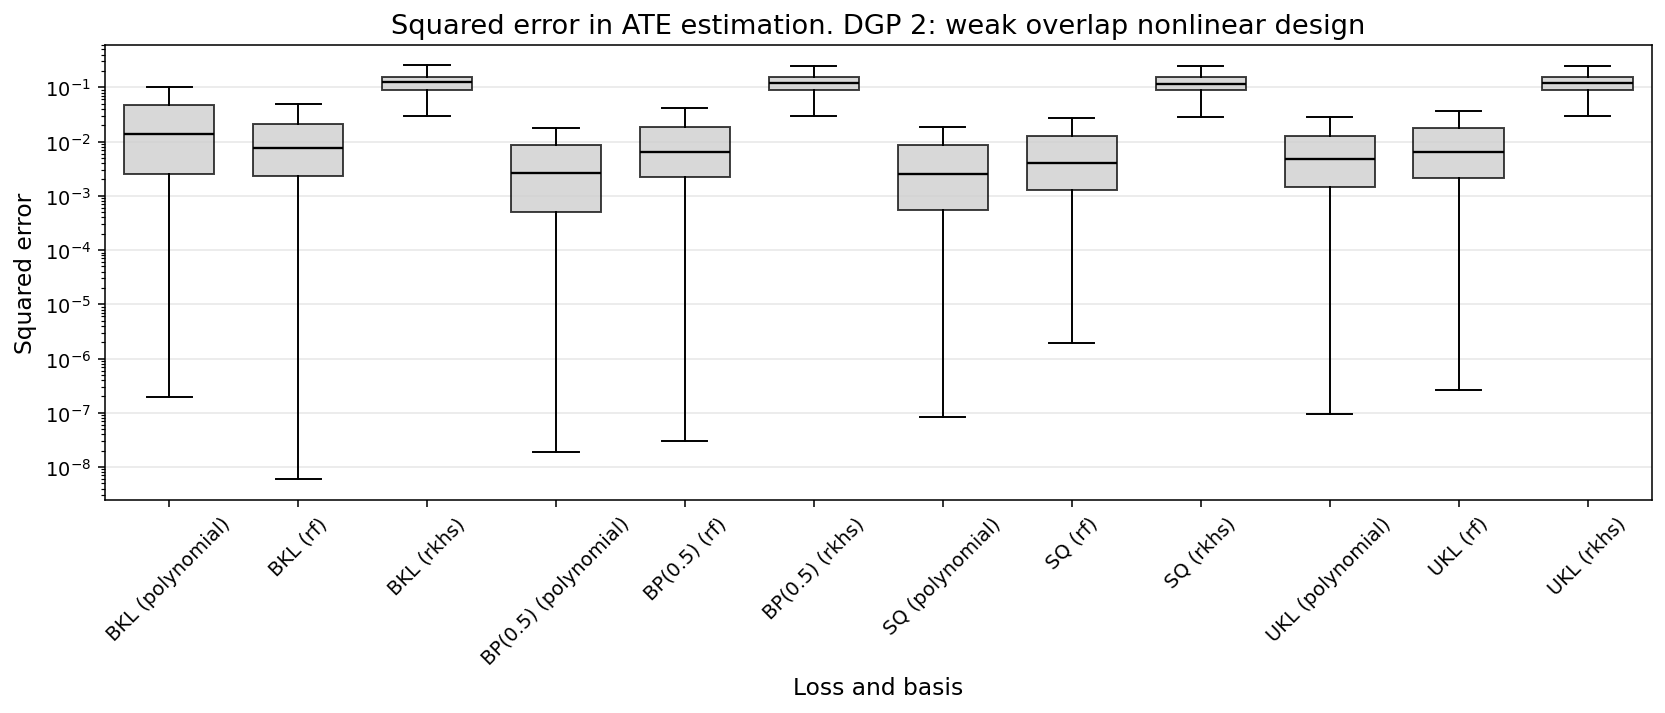

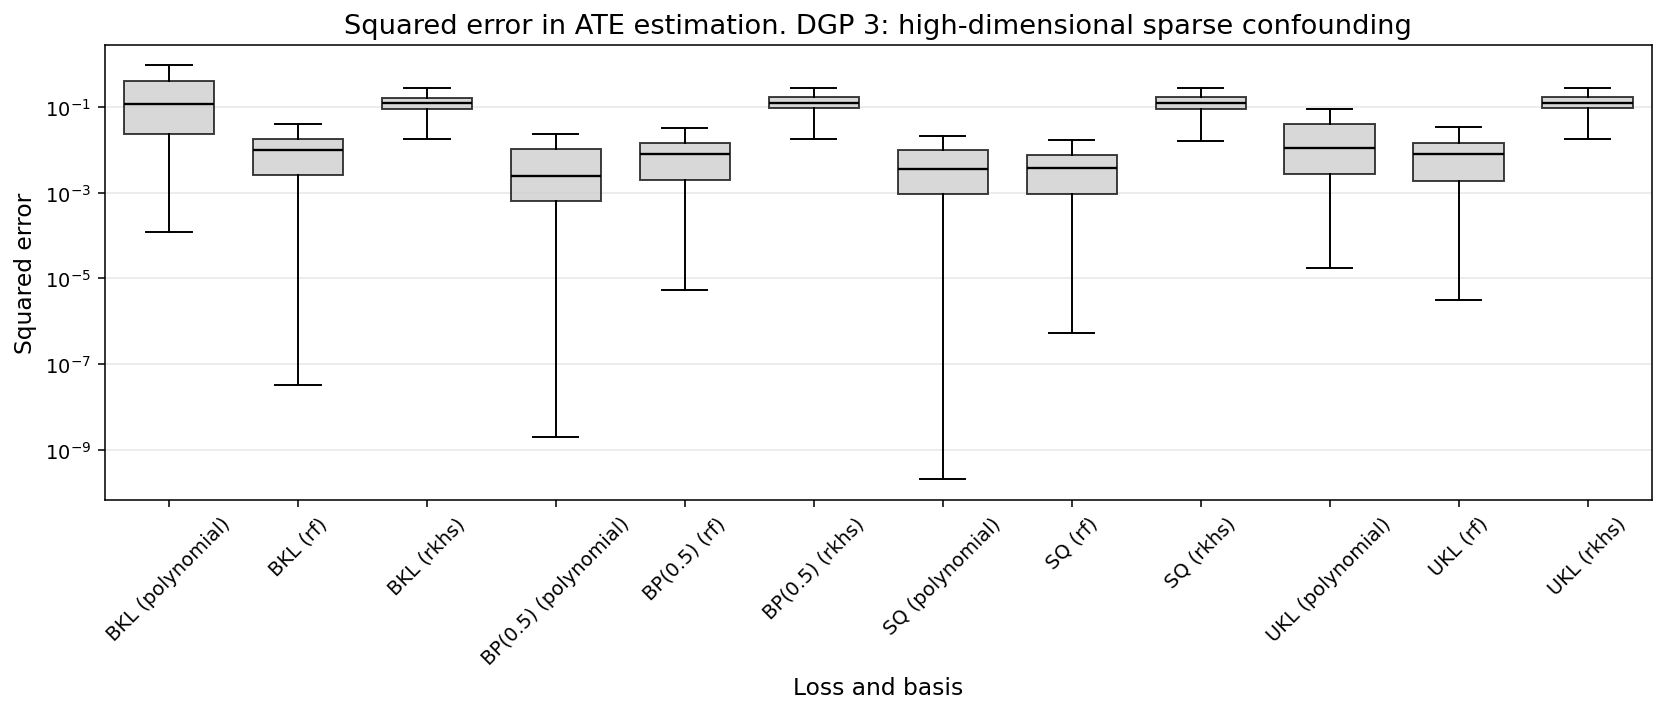

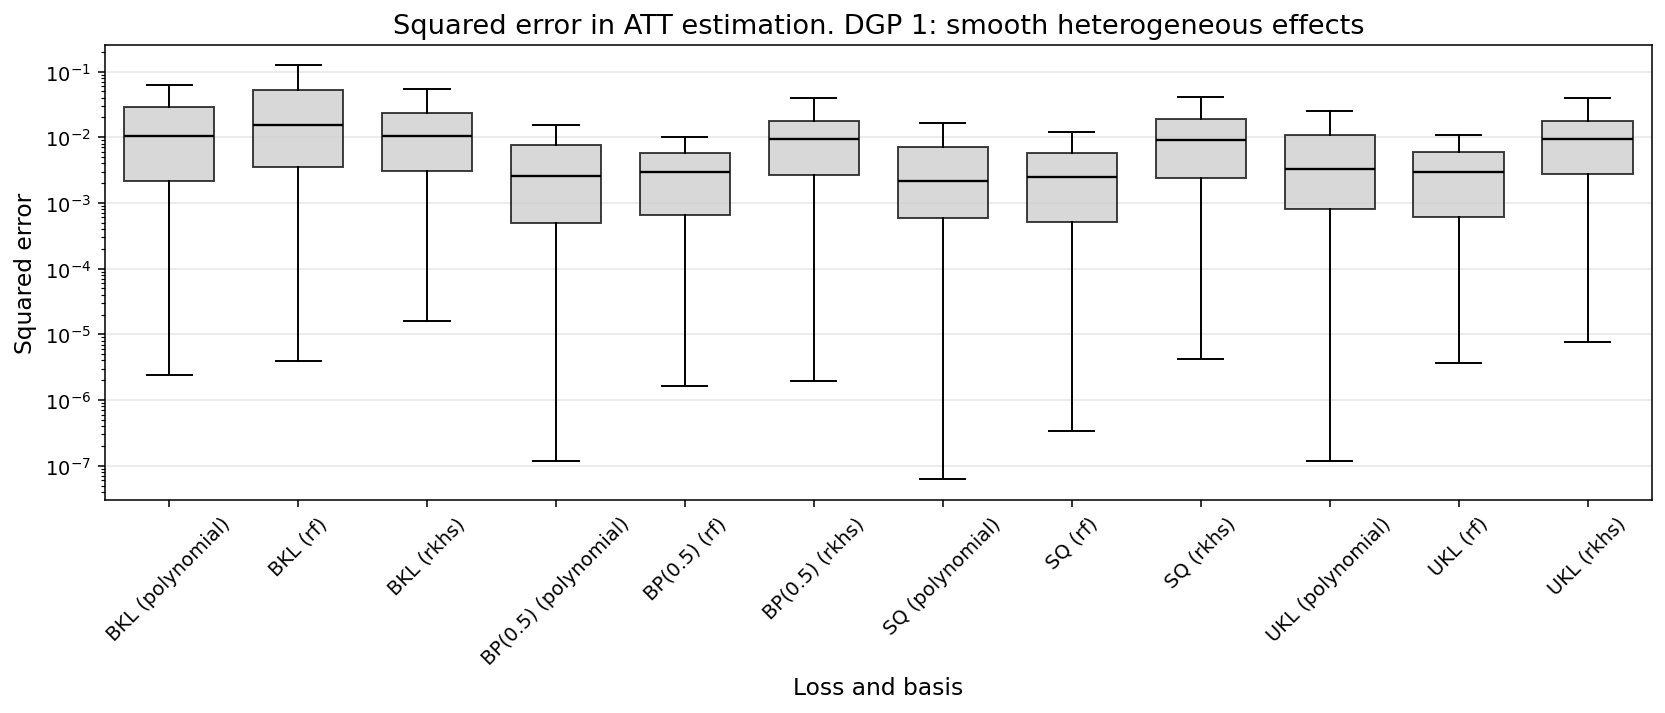

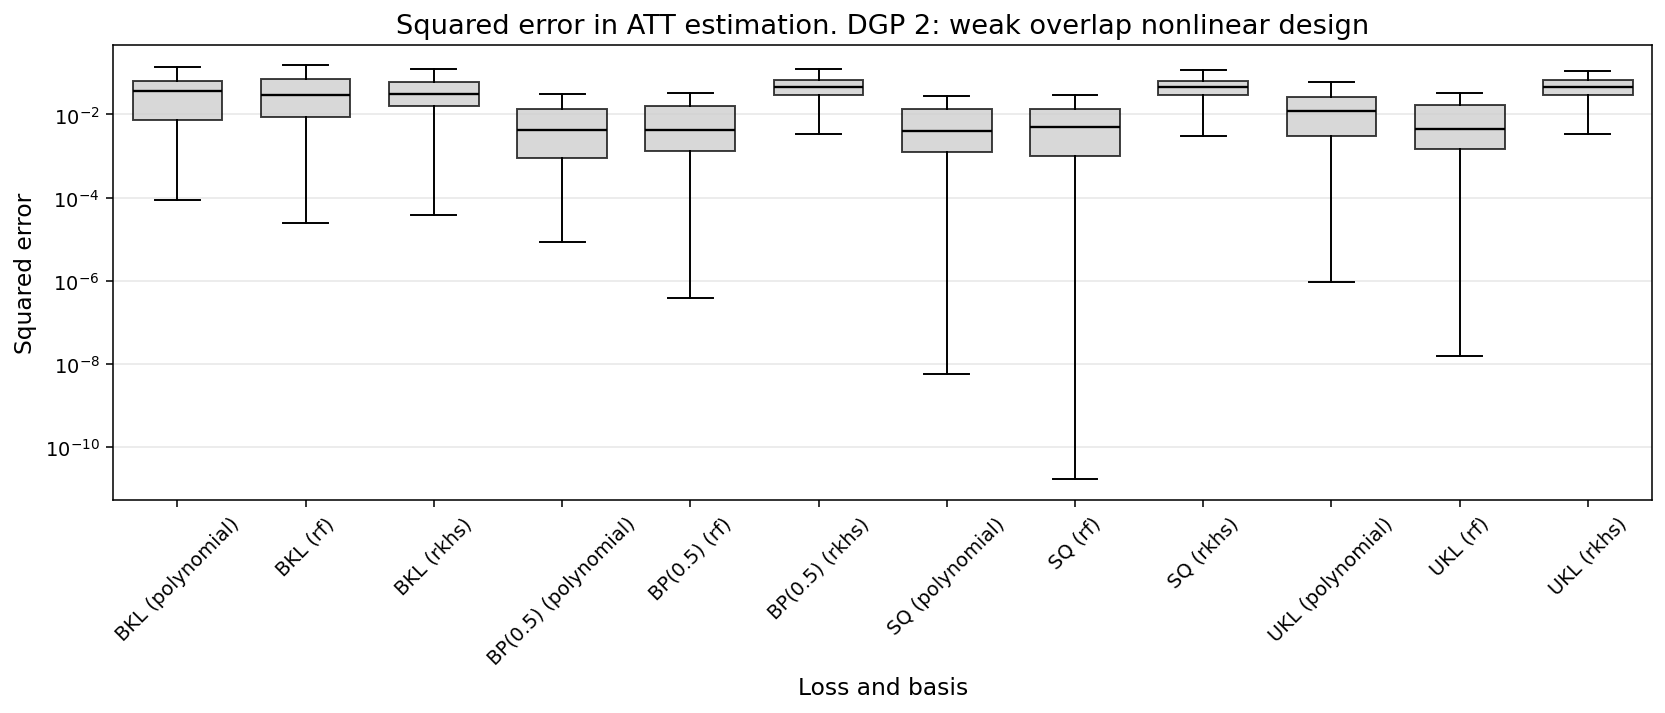

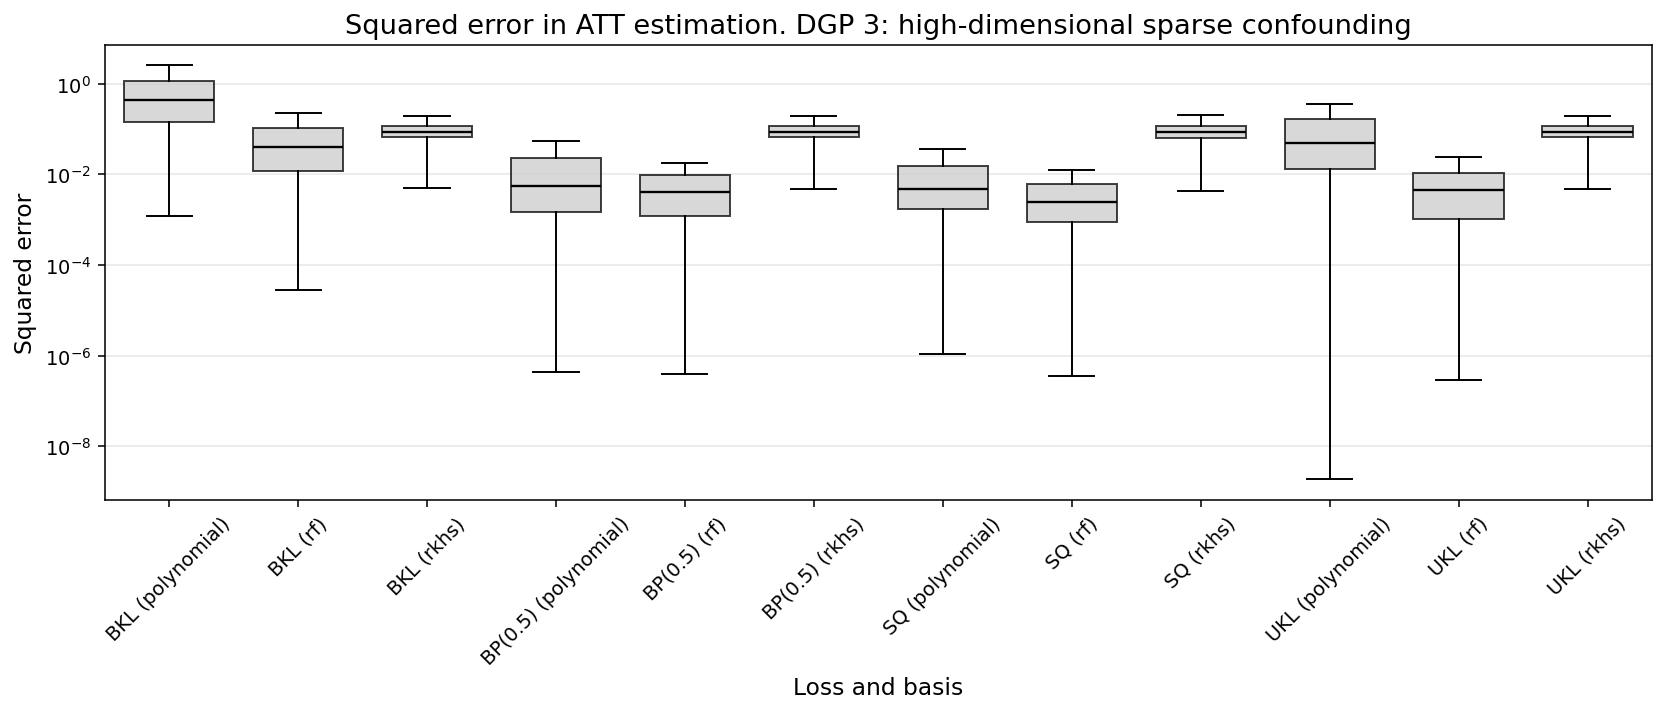

In [5]:
# Box plots of ARW squared error. Edit titles, labels, colors, font sizes, line widths, and scale here.
plot_df = main_compatible[(main_compatible["status"] == "ok") & (main_compatible["estimator"] == "arw")].copy()
plot_df["method"] = plot_df["loss"] + " (" + plot_df["basis"] + ")"
plot_df["squared_error_plot"] = plot_df["squared_error"].clip(lower=PLOT_CONFIG["squared_error_floor"])

for estimand_name in ESTIMANDS:
    for dgp_name in DGP_NAMES:
        panel_df = plot_df[(plot_df["estimand"] == estimand_name) & (plot_df["dgp"] == dgp_name)].copy()
        if panel_df.empty:
            print(f"No plot data for {estimand_name}, {dgp_name}.")
            continue
        fig, ax = plt.subplots(figsize=PLOT_CONFIG["figure_size_wide"], dpi=PLOT_CONFIG["dpi"])
        ordered_methods = sorted(panel_df["method"].unique())
        box_data = [panel_df.loc[panel_df["method"] == m, "squared_error_plot"].dropna().to_numpy() for m in ordered_methods]
        box = ax.boxplot(box_data, tick_labels=[prettify_method(_m) for _m in ordered_methods], widths=PLOT_CONFIG["box_width"], patch_artist=True, showfliers=False)
        for patch, method in zip(box["boxes"], ordered_methods):
            loss_name = method.split(" | ")[0]
            patch.set_facecolor(METHOD_COLORS.get(loss_name, "#CCCCCC"))
            patch.set_alpha(0.75)
        for median in box["medians"]:
            median.set_color("black")
            median.set_linewidth(1.2)
        ax.set_yscale(PLOT_CONFIG["squared_error_y_scale"])
        ax.set_title(f"Squared error in {estimand_name} estimation. {dgp_name}", fontsize=PLOT_CONFIG["title_fontsize"])
        ax.set_xlabel("Loss and basis", fontsize=PLOT_CONFIG["axis_fontsize"])
        ax.set_ylabel("Squared error", fontsize=PLOT_CONFIG["axis_fontsize"])
        ax.tick_params(axis="x", labelrotation=45, labelsize=PLOT_CONFIG["tick_fontsize"])
        ax.tick_params(axis="y", labelsize=PLOT_CONFIG["tick_fontsize"])
        ax.grid(axis="y", alpha=PLOT_CONFIG["grid_alpha"])
        fig.tight_layout()
        plt.show()


## 2. Incompatible loss-link pairs

This subsection intentionally breaks dual linearity. The examples are `BKL loss + logit link`, `SQ loss + logit link`, and `UKL loss + linear link`. The model uses an RKHS basis and cross fitting. RA, RW/IPW, ARW, and TMLE are all displayed.

In [6]:
INCOMPATIBLE_PAIRS = ["BKL loss + logit link", "SQ loss + logit link", "UKL loss + linear link"]
rows = []
for dgp_name in DGP_NAMES:
    for rep in range(N_REPLICATIONS):
        data = make_simulation_data(dgp_name, n=SAMPLE_SIZE, seed=200000 + 1009 * rep)
        for pair_name in INCOMPATIBLE_PAIRS:
            for estimand in ESTIMANDS:
                fit_rows = fit_one_incompatible(
                    data,
                    estimand=estimand,
                    pair_name=pair_name,
                    cross_fit=True,
                    lam=RIEZ_LAMBDA_MAIN,
                    basis_features=RIEZ_FEATURES,
                    folds=FOLDS,
                    random_state=rep,
                )
                for row in fit_rows:
                    row["dgp"] = dgp_name
                    row["replication"] = rep
                rows.extend(fit_rows)
incompatible_results = pd.DataFrame(rows)
incompatible_summary = summarize_estimates(incompatible_results, ["dgp", "estimand", "loss_link_pair", "estimator"])

for estimand_name in ESTIMANDS:
    table_df = incompatible_summary[incompatible_summary["estimand"] == estimand_name].copy()
    if table_df.empty:
        print(f"No rows for {estimand_name}.")
        continue
    table_df = table_df.drop(columns=["estimand"])
    table_df = table_df.sort_values(["dgp", "loss_link_pair", "estimator"])
    display_table(table_df, caption=f"Main simulation incompatible loss-link pairs: {estimand_name}")


,dgp,loss_link_pair,estimator,estimate_mean,estimate_std,se_mean,mse,alpha_abs_p95_mean,alpha_abs_max_mean,max_abs_smd_weighted_mean,ess_treated_mean,ess_control_mean,rmse,coverage
0,DGP 1: smooth heterogeneous effects,BKL loss + logit link,arw,1.0774,0.0757,0.0818,0.0113,3.5961,11.5754,0.1859,508.4767,510.0280,0.1065,0.8600
1,DGP 1: smooth heterogeneous effects,BKL loss + logit link,ra,1.0800,0.0593,0.0301,0.0098,3.5961,11.5754,0.1859,508.4767,510.0280,0.0992,0.3600
2,DGP 1: smooth heterogeneous effects,BKL loss + logit link,rw,1.1470,0.0644,0.0922,0.0252,3.5961,11.5754,0.1859,508.4767,510.0280,0.1587,0.7100
3,DGP 1: smooth heterogeneous effects,BKL loss + logit link,tmle,1.0778,0.0718,0.0817,0.0109,3.5961,11.5754,0.1859,508.4767,510.0280,0.1042,0.8700
4,DGP 1: smooth heterogeneous effects,SQ loss + logit link,arw,1.0830,0.0635,0.0692,0.0107,2.0351,2.0784,0.5567,599.5671,600.3464,0.1035,0.8200
5,DGP 1: smooth heterogeneous effects,SQ loss + logit link,ra,1.0800,0.0593,0.0301,0.0098,2.0351,2.0784,0.5567,599.5671,600.3464,0.0992,0.3600
6,DGP 1: smooth heterogeneous effects,SQ loss + logit link,rw,1.3097,0.0735,0.0874,0.1000,2.0351,2.0784,0.5567,599.5671,600.3464,0.3162,0.0300
7,DGP 1: smooth heterogeneous effects,SQ loss + logit link,tmle,1.0830,0.0636,0.0692,0.0107,2.0351,2.0784,0.5567,599.5671,600.3464,0.1035,0.8200
8,DGP 1: smooth heterogeneous effects,UKL loss + linear link,arw,1.0820,0.0592,0.0456,0.0101,1.5330,1.8379,0.5135,590.9553,591.7833,0.1003,0.5400
9,DGP 1: smooth heterogeneous effects,UKL loss + linear link,ra,1.0800,0.0593,0.0301,0.0098,1.5330,1.8379,0.5135,590.9553,591.7833,0.0992,0.3600


,dgp,loss_link_pair,estimator,estimate_mean,estimate_std,se_mean,mse,alpha_abs_p95_mean,alpha_abs_max_mean,max_abs_smd_weighted_mean,ess_treated_mean,ess_control_mean,rmse,coverage
12,DGP 1: smooth heterogeneous effects,BKL loss + logit link,arw,1.1863,0.0917,0.0995,0.0103,3.8889,17.5127,0.1989,599.4709,365.1952,0.1016,0.9600
13,DGP 1: smooth heterogeneous effects,BKL loss + logit link,ra,1.1903,0.0719,0.0541,0.0078,3.8889,17.5127,0.1989,599.4709,365.1952,0.0886,0.8100
14,DGP 1: smooth heterogeneous effects,BKL loss + logit link,rw,1.1991,0.0698,0.0999,0.0083,3.8889,17.5127,0.1989,599.4709,365.1952,0.0909,0.9700
15,DGP 1: smooth heterogeneous effects,BKL loss + logit link,tmle,1.1875,0.0842,0.0989,0.0092,3.8889,17.5127,0.1989,599.4709,365.1952,0.0959,0.9700
16,DGP 1: smooth heterogeneous effects,SQ loss + logit link,arw,1.1933,0.0753,0.0822,0.0084,2.0565,2.1058,0.5566,599.4709,600.2623,0.0919,0.9300
17,DGP 1: smooth heterogeneous effects,SQ loss + logit link,ra,1.1903,0.0719,0.0541,0.0078,2.0565,2.1058,0.5566,599.4709,600.2623,0.0886,0.8100
18,DGP 1: smooth heterogeneous effects,SQ loss + logit link,rw,1.3153,0.0706,0.0877,0.0360,2.0565,2.1058,0.5566,599.4709,600.2623,0.1897,0.4700
19,DGP 1: smooth heterogeneous effects,SQ loss + logit link,tmle,1.1933,0.0753,0.0822,0.0084,2.0565,2.1058,0.5566,599.4709,600.2623,0.0919,0.9300
20,DGP 1: smooth heterogeneous effects,UKL loss + linear link,arw,1.1922,0.0719,0.0635,0.0079,1.5352,1.8525,0.5126,591.0175,590.7699,0.0890,0.8600
21,DGP 1: smooth heterogeneous effects,UKL loss + linear link,ra,1.1903,0.0719,0.0541,0.0078,1.5352,1.8525,0.5126,591.0175,590.7699,0.0886,0.8100


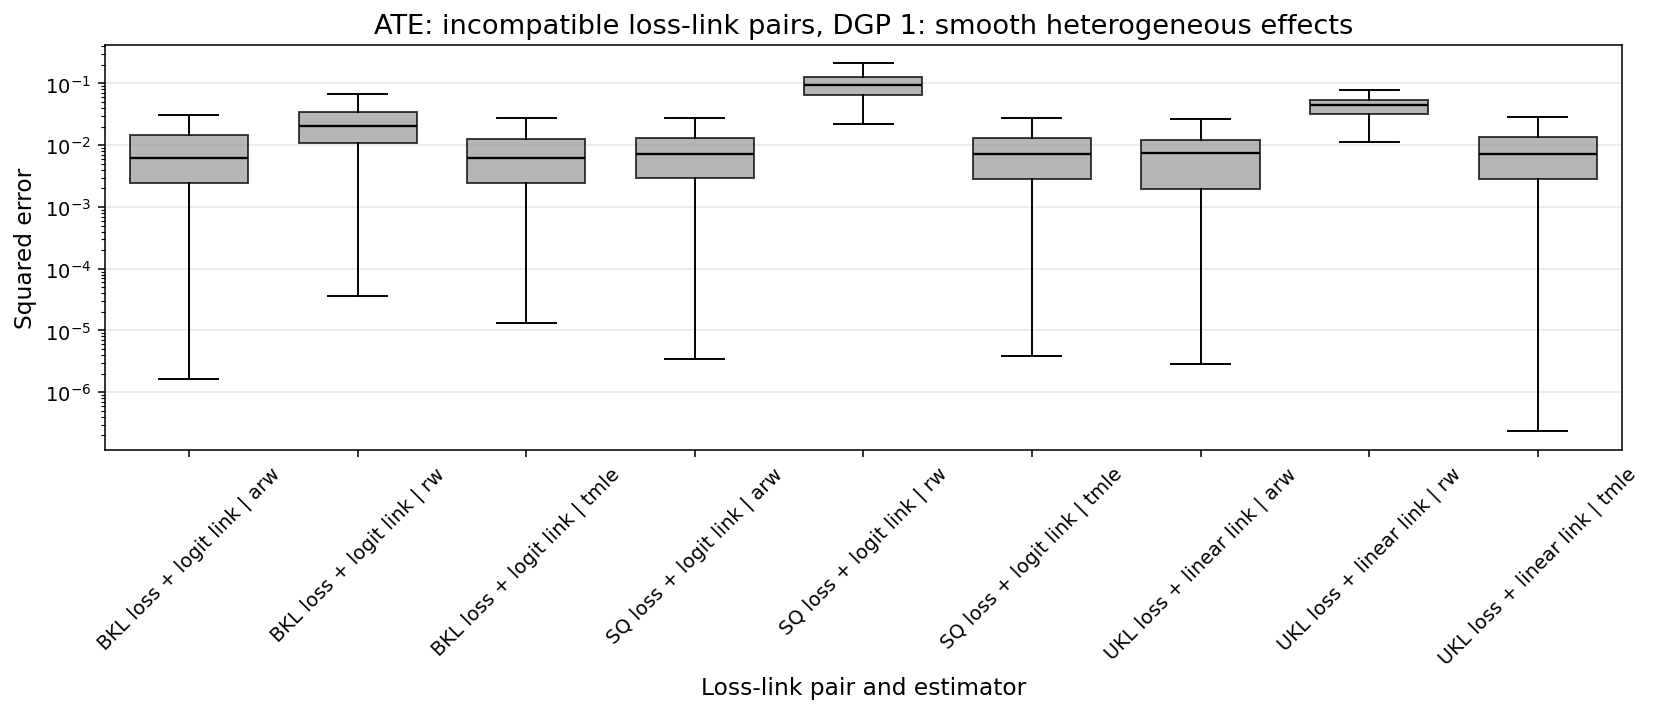

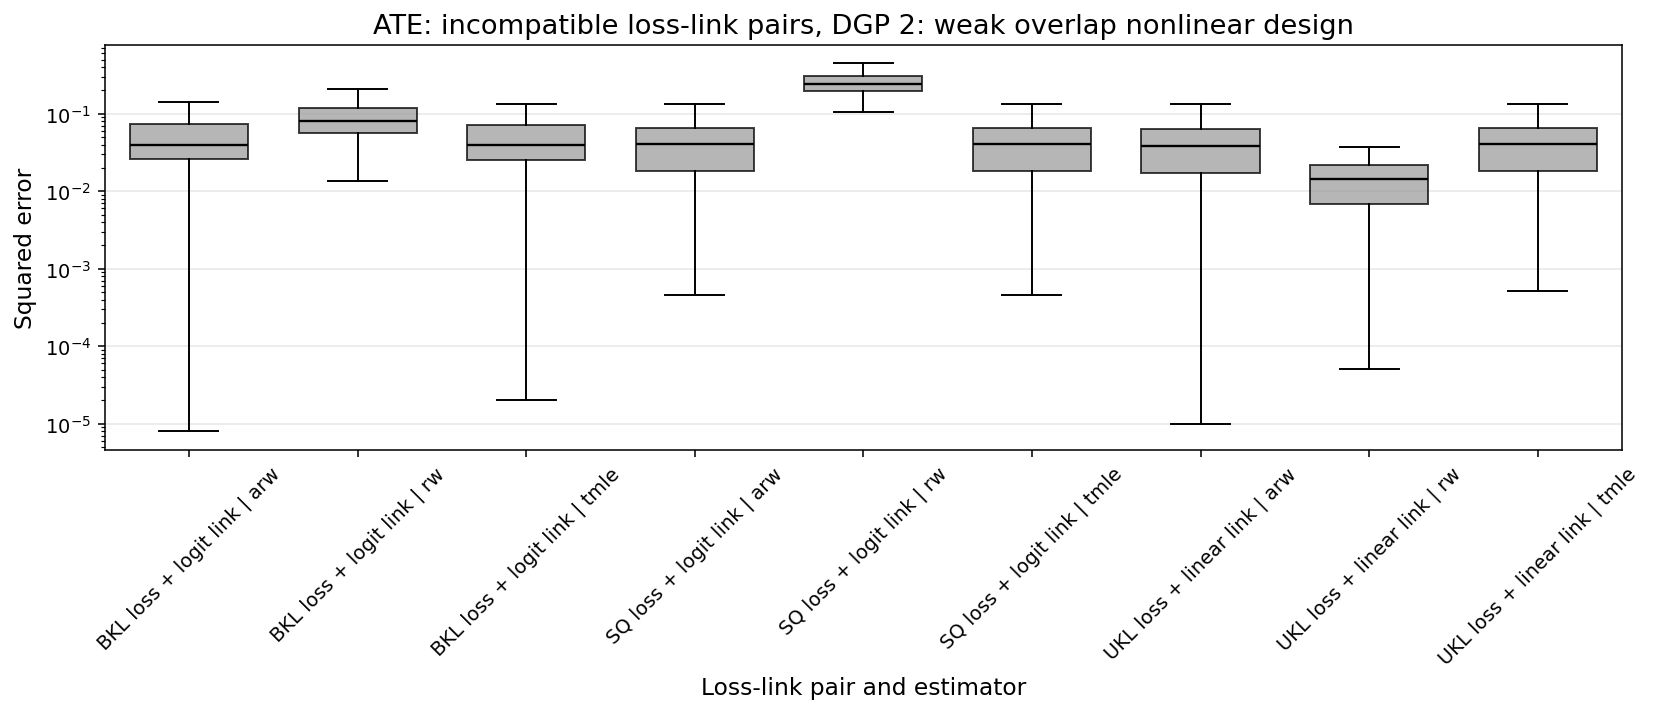

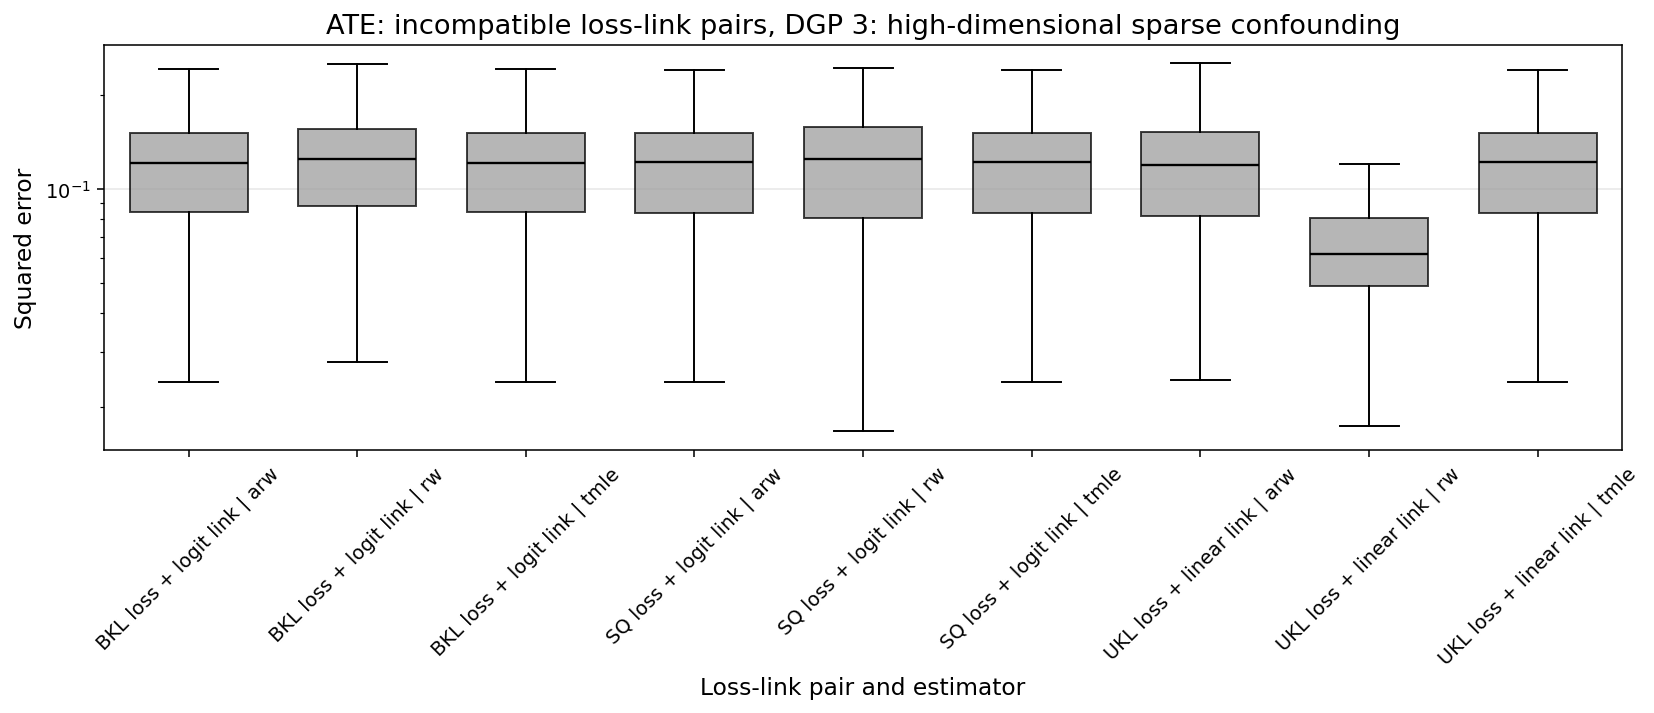

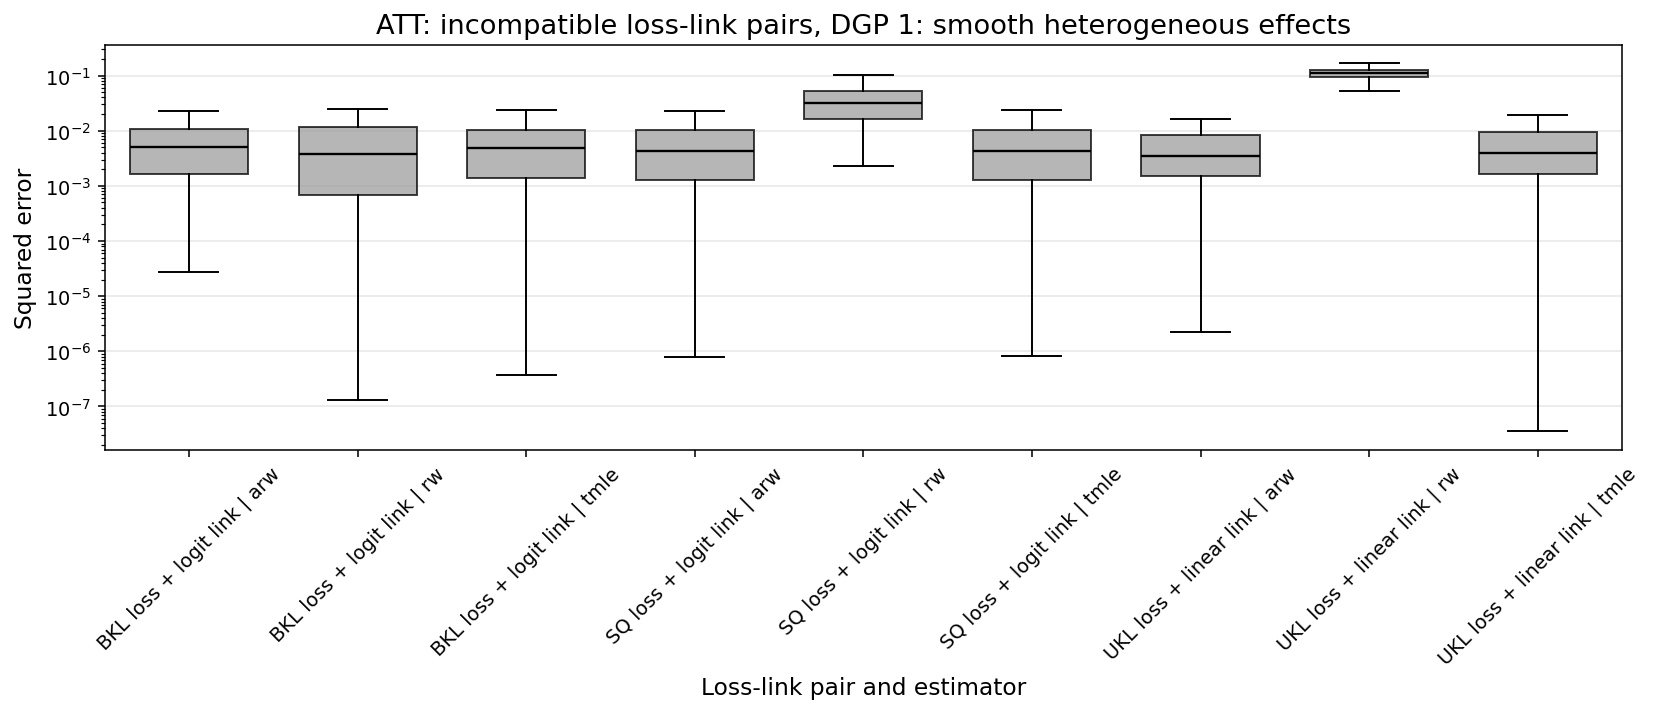

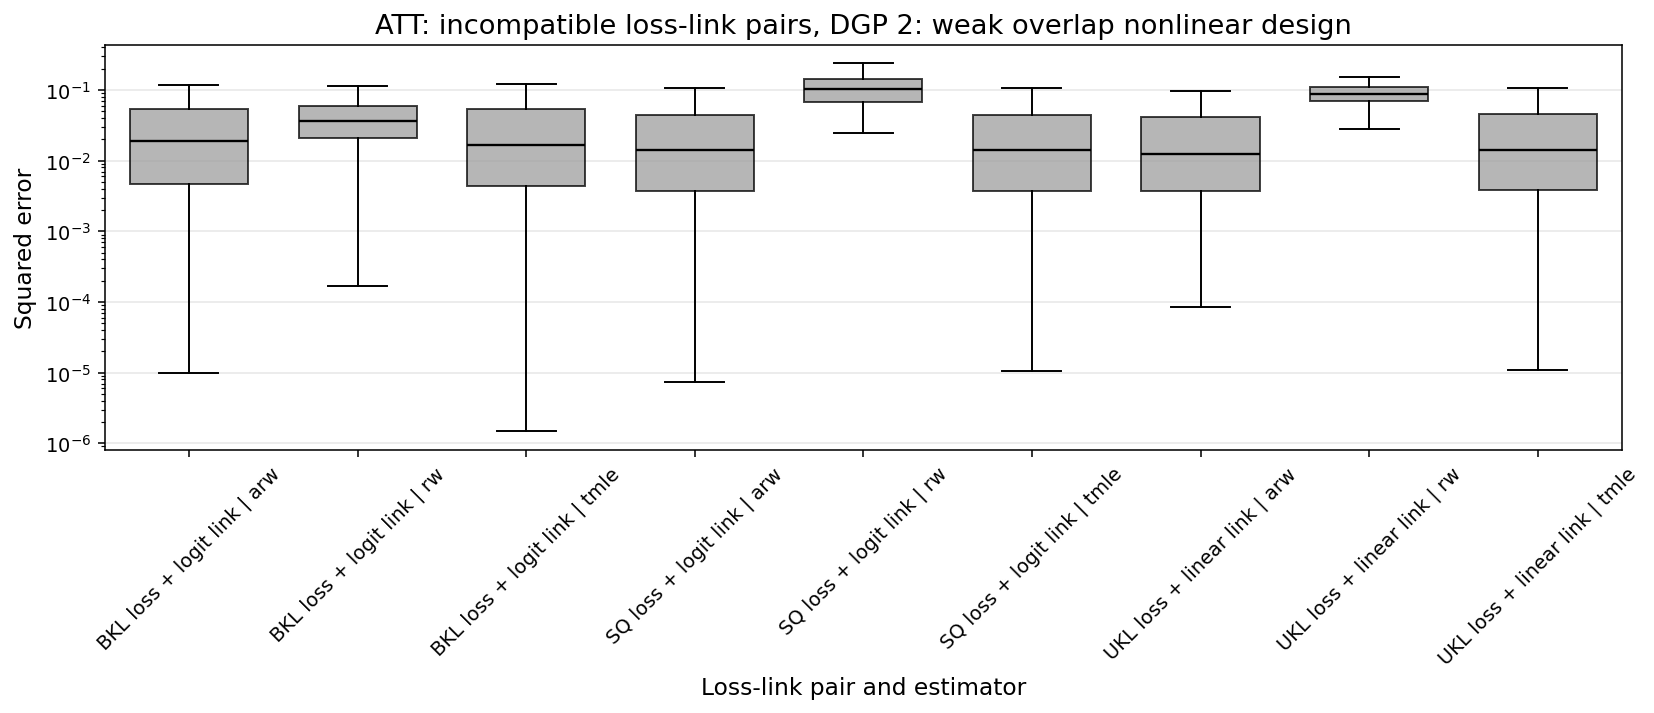

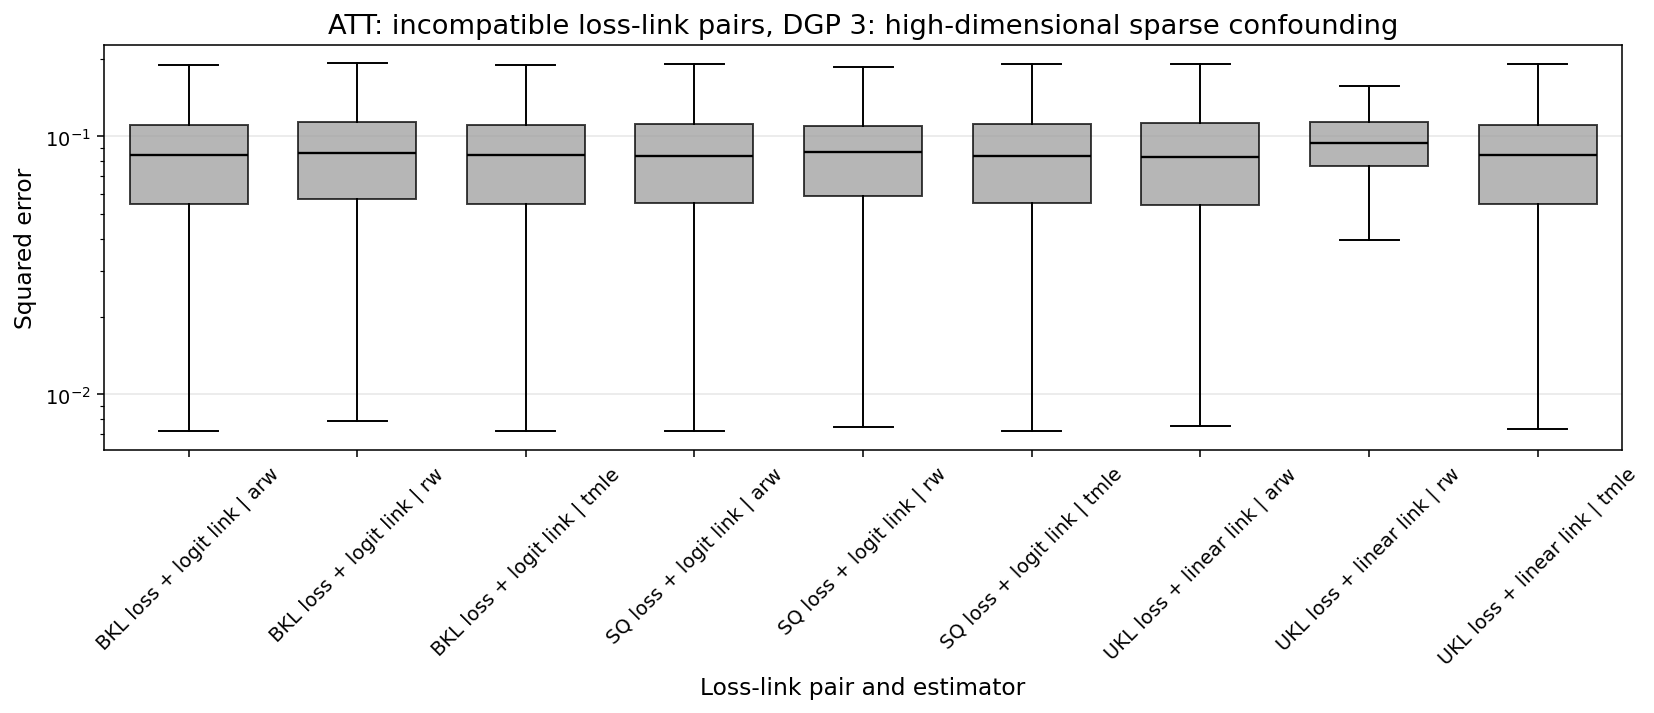

In [7]:
# Box plots for incompatible loss-link pairs. ATE and ATT are deliberately separated.
plot_df = incompatible_results[(incompatible_results["status"] == "ok") & (incompatible_results["estimator"].isin(["rw", "arw", "tmle"]))].copy()
plot_df["method"] = plot_df["loss_link_pair"] + " | " + plot_df["estimator"]
plot_df["squared_error_plot"] = plot_df["squared_error"].clip(lower=PLOT_CONFIG["squared_error_floor"])

for estimand_name in ESTIMANDS:
    for dgp_name in DGP_NAMES:
        panel_df = plot_df[(plot_df["estimand"] == estimand_name) & (plot_df["dgp"] == dgp_name)].copy()
        if panel_df.empty:
            print(f"No plot data for {estimand_name}, {dgp_name}.")
            continue
        fig, ax = plt.subplots(figsize=PLOT_CONFIG["figure_size_wide"], dpi=PLOT_CONFIG["dpi"])
        ordered_methods = sorted(panel_df["method"].unique())
        box_data = [panel_df.loc[panel_df["method"] == m, "squared_error_plot"].dropna().to_numpy() for m in ordered_methods]
        box = ax.boxplot(box_data, tick_labels=[prettify_method(_m) for _m in ordered_methods], widths=PLOT_CONFIG["box_width"], patch_artist=True, showfliers=False)
        for patch in box["boxes"]:
            patch.set_facecolor("#9E9E9E")
            patch.set_alpha(0.75)
        for median in box["medians"]:
            median.set_color("black")
            median.set_linewidth(1.2)
        ax.set_yscale(PLOT_CONFIG["squared_error_y_scale"])
        ax.set_title(f"{estimand_name}: incompatible loss-link pairs, {dgp_name}", fontsize=PLOT_CONFIG["title_fontsize"])
        ax.set_xlabel("Loss-link pair and estimator", fontsize=PLOT_CONFIG["axis_fontsize"])
        ax.set_ylabel("Squared error", fontsize=PLOT_CONFIG["axis_fontsize"])
        ax.tick_params(axis="x", labelrotation=45, labelsize=PLOT_CONFIG["tick_fontsize"])
        ax.tick_params(axis="y", labelsize=PLOT_CONFIG["tick_fontsize"])
        ax.grid(axis="y", alpha=PLOT_CONFIG["grid_alpha"])
        fig.tight_layout()
        plt.show()


## 3. Regularization path under compatible loss-link pairs

The model is RKHS. We compare cross fitting with no cross fitting and vary the Riesz regularization parameter. The main plot uses MSE on the y-axis and λ on the x-axis.

In [8]:
LAMBDA_GRID = np.array([1e-1, 3e-1, 1.0, 3.0], dtype=float)
rows = []
for dgp_name in DGP_NAMES:
    for rep in range(N_REPLICATIONS):
        data = make_simulation_data(dgp_name, n=SAMPLE_SIZE, seed=300000 + 1009 * rep)
        for cross_fit in [True, False]:
            for lam in LAMBDA_GRID:
                for loss_spec in COMPATIBLE_LOSSES:
                    for estimand in ESTIMANDS:
                        fit_rows = fit_one_grr(
                            data,
                            estimand=estimand,
                            loss_spec=loss_spec,
                            basis_kind="rkhs",
                            basis_mode="regressor",
                            cross_fit=cross_fit,
                            lam=float(lam),
                            basis_features=RIEZ_FEATURES,
                            degree=POLYNOMIAL_DEGREE,
                            folds=FOLDS,
                            estimators=ESTIMATORS_ALL,
                            random_state=rep,
                        )
                        for row in fit_rows:
                            row["dgp"] = dgp_name
                            row["replication"] = rep
                        rows.extend(fit_rows)
regularization_results = pd.DataFrame(rows)
regularization_summary = summarize_estimates(regularization_results, ["dgp", "estimand", "cross_fit", "lambda_riesz", "loss", "estimator"])

for estimand_name in ESTIMANDS:
    table_df = regularization_summary[regularization_summary["estimand"] == estimand_name].copy()
    if table_df.empty:
        print(f"No rows for {estimand_name}.")
        continue
    table_df = table_df.drop(columns=["estimand"])
    table_df = table_df.sort_values(["dgp", "cross_fit", "lambda_riesz", "loss", "estimator"])
    display_table(table_df, caption=f"Regularization path summary: {estimand_name}")


,dgp,cross_fit,lambda_riesz,loss,estimator,estimate_mean,estimate_std,se_mean,mse,alpha_abs_p95_mean,alpha_abs_max_mean,max_abs_smd_weighted_mean,ess_treated_mean,ess_control_mean,rmse,coverage
0,DGP 1: smooth heterogeneous effects,False,0.1000,BKL,arw,1.1348,0.0608,0.0699,0.0213,2.5185,3.1418,0.4804,592.0147,594.8834,0.1459,0.5200
1,DGP 1: smooth heterogeneous effects,False,0.1000,BKL,ra,1.1375,0.0611,0.0147,0.0220,2.5185,3.1418,0.4804,592.0147,594.8834,0.1484,0.0200
2,DGP 1: smooth heterogeneous effects,False,0.1000,BKL,rw,1.3873,0.0740,0.0961,0.1544,2.5185,3.1418,0.4804,592.0147,594.8834,0.3930,0.0100
3,DGP 1: smooth heterogeneous effects,False,0.1000,BKL,tmle,1.1350,0.0608,0.0699,0.0213,2.5185,3.1418,0.4804,592.0147,594.8834,0.1460,0.5200
4,DGP 1: smooth heterogeneous effects,False,0.1000,BP(0.5),arw,1.1388,0.0611,0.0635,0.0224,2.1599,2.3994,0.5181,597.4050,600.3208,0.1496,0.4000
5,DGP 1: smooth heterogeneous effects,False,0.1000,BP(0.5),ra,1.1375,0.0611,0.0147,0.0220,2.1599,2.3994,0.5181,597.4050,600.3208,0.1484,0.0200
6,DGP 1: smooth heterogeneous effects,False,0.1000,BP(0.5),rw,1.2912,0.0709,0.0870,0.0889,2.1599,2.3994,0.5181,597.4050,600.3208,0.2981,0.0400
7,DGP 1: smooth heterogeneous effects,False,0.1000,BP(0.5),tmle,1.1388,0.0611,0.0635,0.0224,2.1599,2.3994,0.5181,597.4050,600.3208,0.1496,0.4000
8,DGP 1: smooth heterogeneous effects,False,0.1000,SQ,arw,1.1379,0.0611,0.0480,0.0221,1.8447,2.2029,0.4978,590.4030,593.4103,0.1488,0.2400
9,DGP 1: smooth heterogeneous effects,False,0.1000,SQ,ra,1.1375,0.0611,0.0147,0.0220,1.8447,2.2029,0.4978,590.4030,593.4103,0.1484,0.0200


,dgp,cross_fit,lambda_riesz,loss,estimator,estimate_mean,estimate_std,se_mean,mse,alpha_abs_p95_mean,alpha_abs_max_mean,max_abs_smd_weighted_mean,ess_treated_mean,ess_control_mean,rmse,coverage
128,DGP 1: smooth heterogeneous effects,False,0.1000,BKL,arw,1.2041,0.0642,0.0800,0.0082,3.1085,17.3232,0.2613,598.5188,401.0356,0.0908,0.9500
129,DGP 1: smooth heterogeneous effects,False,0.1000,BKL,ra,1.2141,0.0633,0.0409,0.0096,3.1085,17.3232,0.2613,598.5188,401.0356,0.0979,0.4700
130,DGP 1: smooth heterogeneous effects,False,0.1000,BKL,rw,1.2376,0.0638,0.0952,0.0138,3.1085,17.3232,0.2613,598.5188,401.0356,0.1176,0.9400
131,DGP 1: smooth heterogeneous effects,False,0.1000,BKL,tmle,1.2005,0.0662,0.0797,0.0080,3.1085,17.3232,0.2613,598.5188,401.0356,0.0895,0.9400
132,DGP 1: smooth heterogeneous effects,False,0.1000,BP(0.5),arw,1.2153,0.0633,0.0698,0.0098,2.1299,2.8181,0.4967,597.0905,591.9177,0.0990,0.8200
133,DGP 1: smooth heterogeneous effects,False,0.1000,BP(0.5),ra,1.2141,0.0633,0.0409,0.0096,2.1299,2.8181,0.4967,597.0905,591.9177,0.0979,0.4700
134,DGP 1: smooth heterogeneous effects,False,0.1000,BP(0.5),rw,1.1765,0.0631,0.0791,0.0047,2.1299,2.8181,0.4967,597.0905,591.9177,0.0683,0.9800
135,DGP 1: smooth heterogeneous effects,False,0.1000,BP(0.5),tmle,1.2155,0.0633,0.0698,0.0098,2.1299,2.8181,0.4967,597.0905,591.9177,0.0991,0.8200
136,DGP 1: smooth heterogeneous effects,False,0.1000,SQ,arw,1.2150,0.0633,0.0618,0.0097,1.8621,2.2925,0.5072,590.9948,590.5869,0.0987,0.8000
137,DGP 1: smooth heterogeneous effects,False,0.1000,SQ,ra,1.2141,0.0633,0.0409,0.0096,1.8621,2.2925,0.5072,590.9948,590.5869,0.0979,0.4700


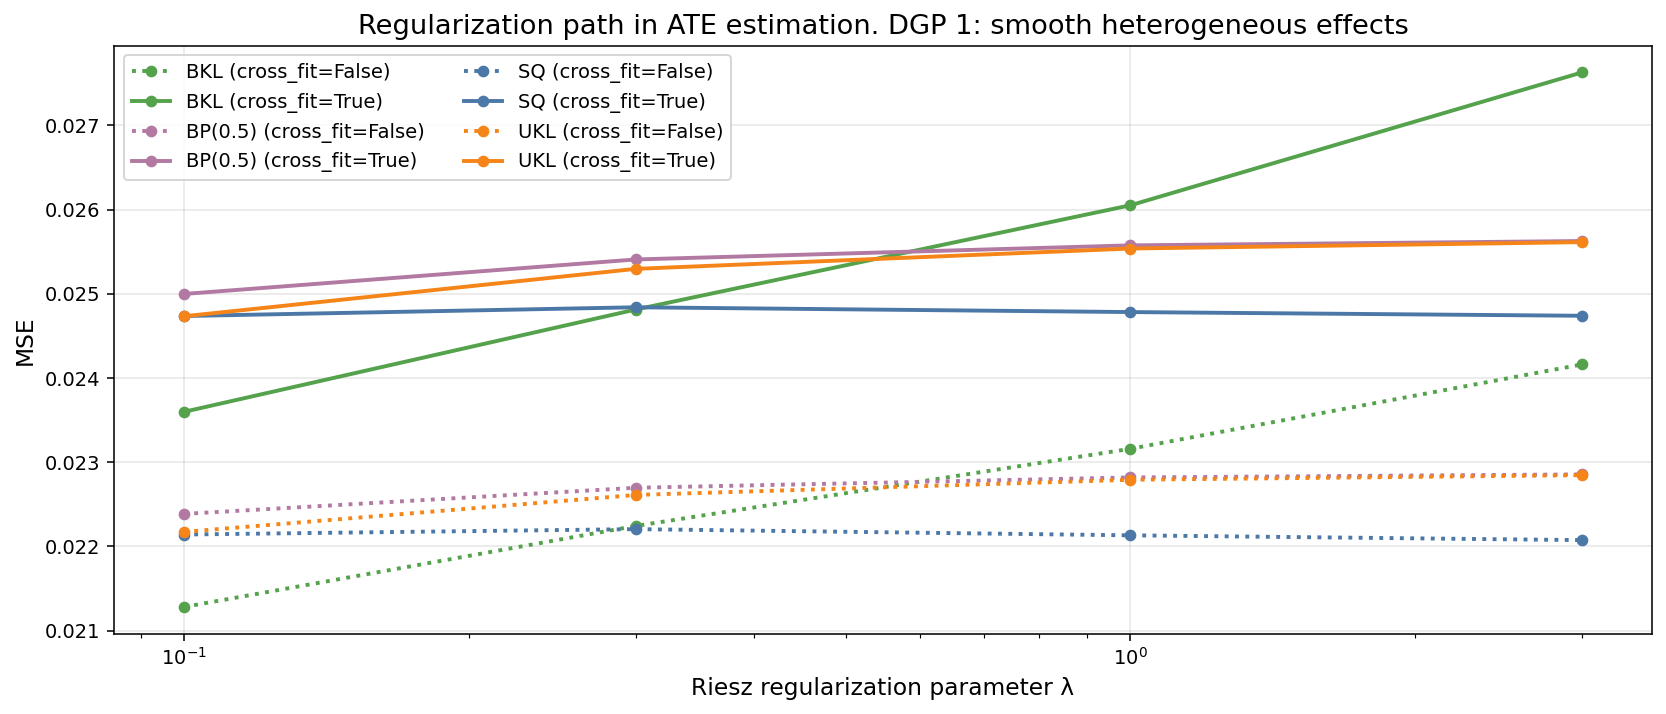

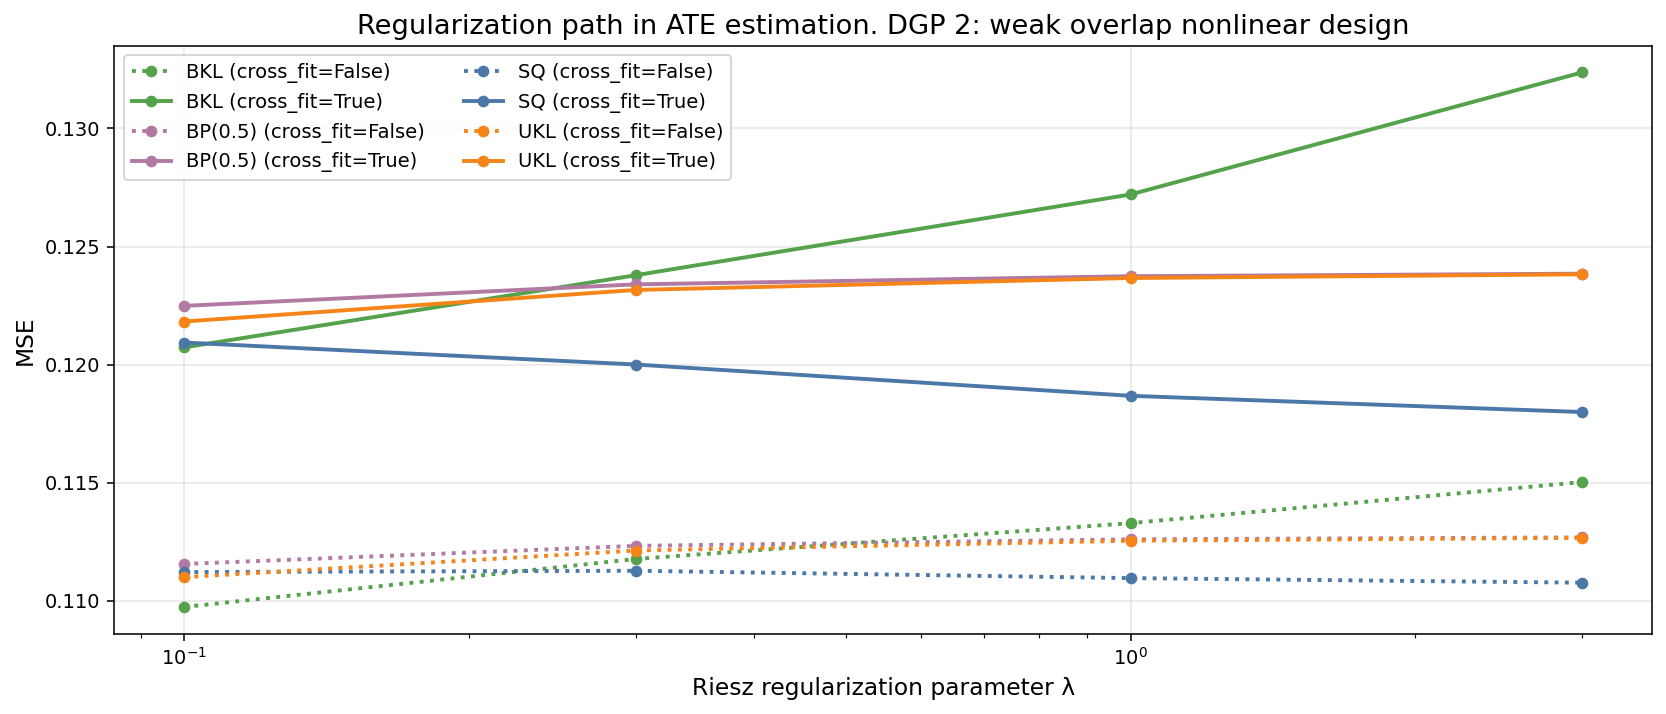

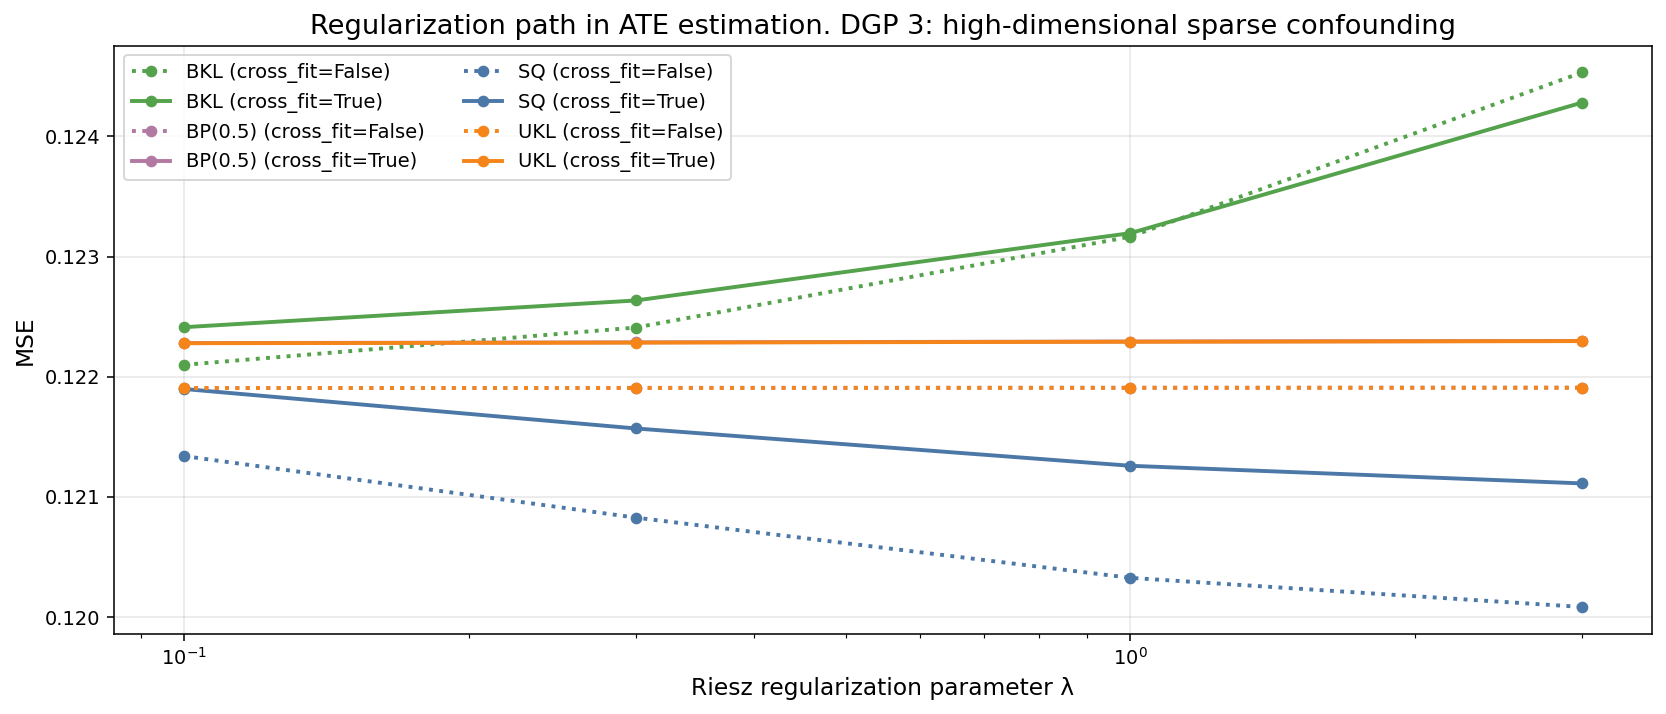

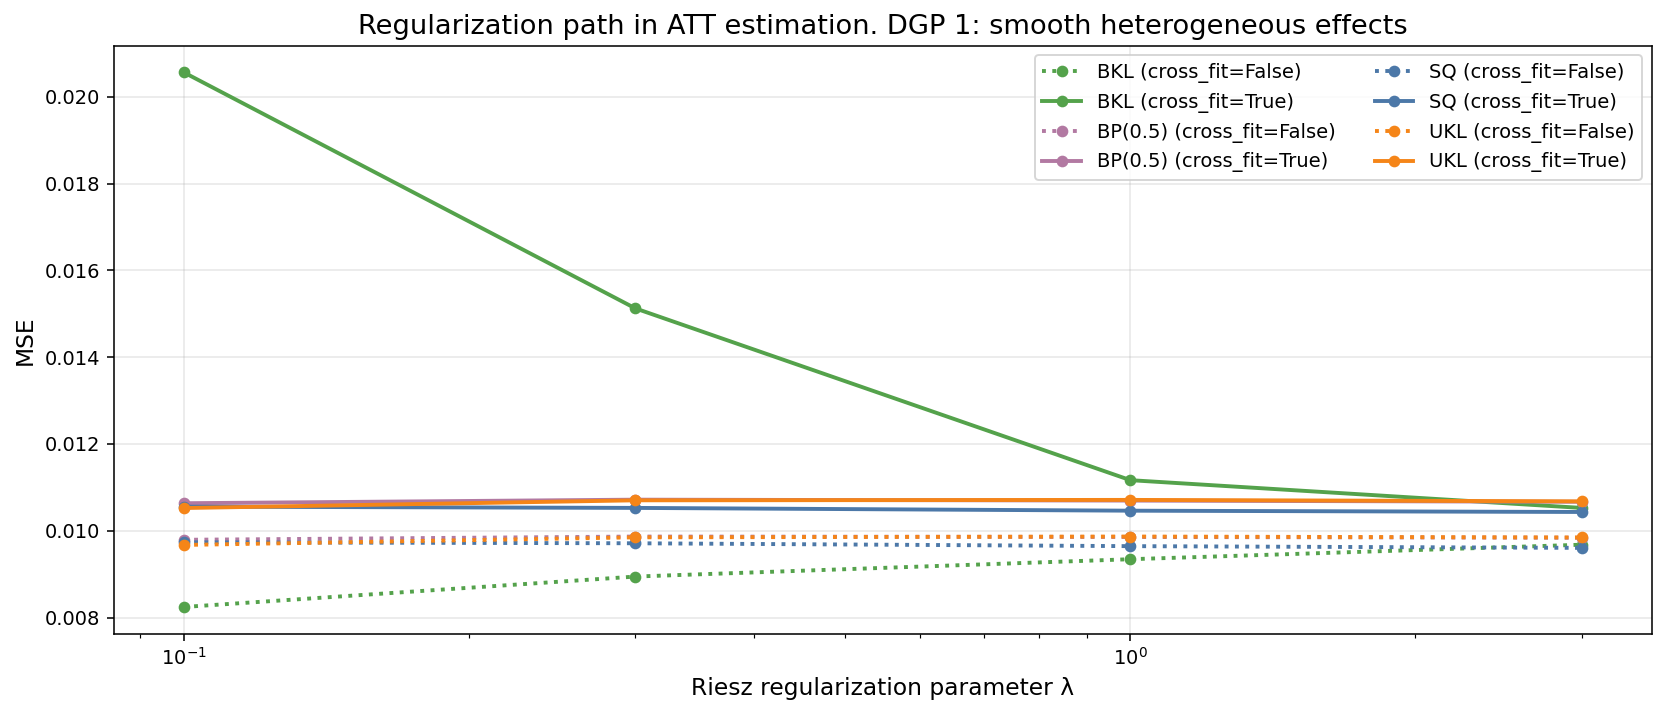

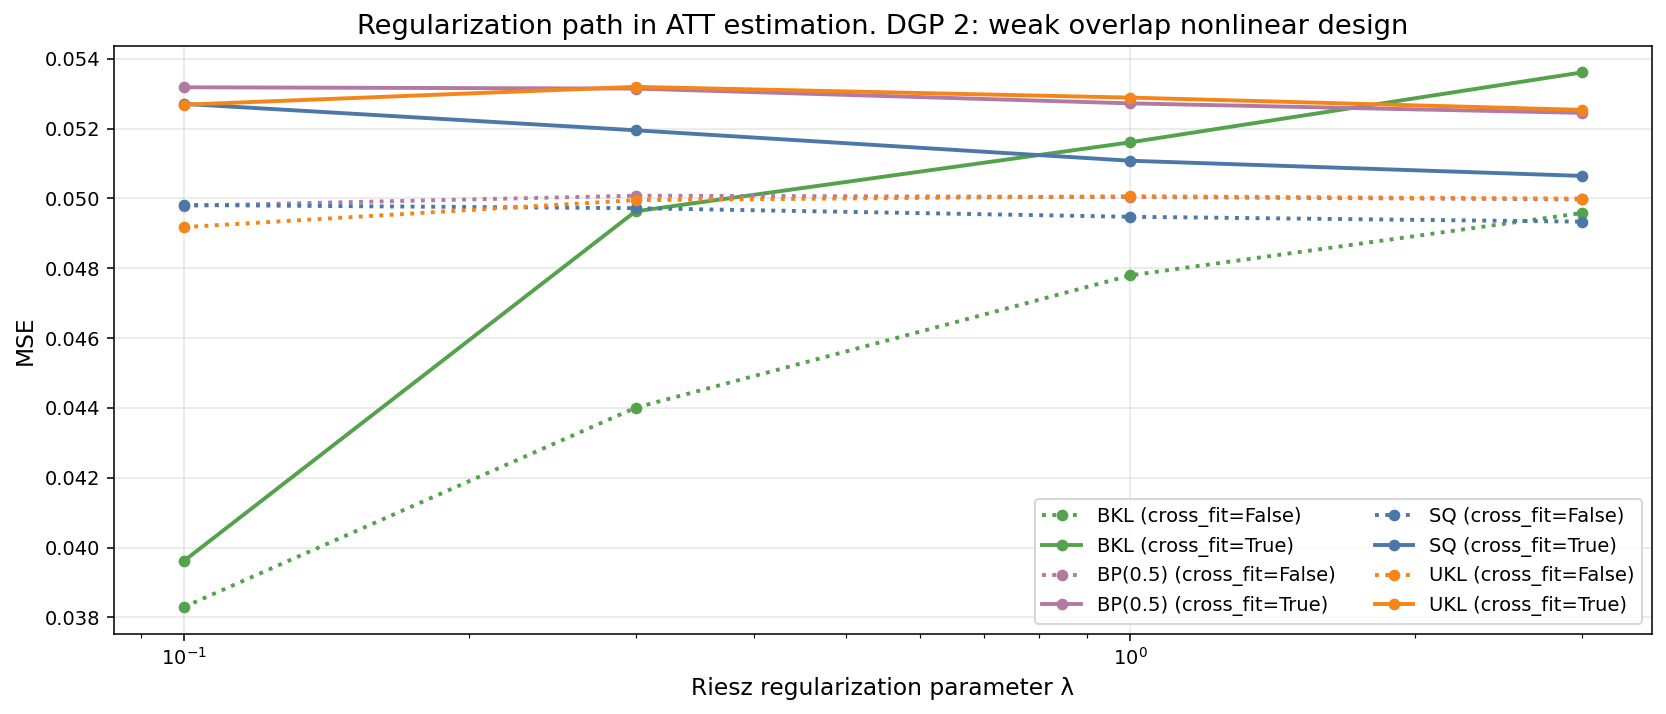

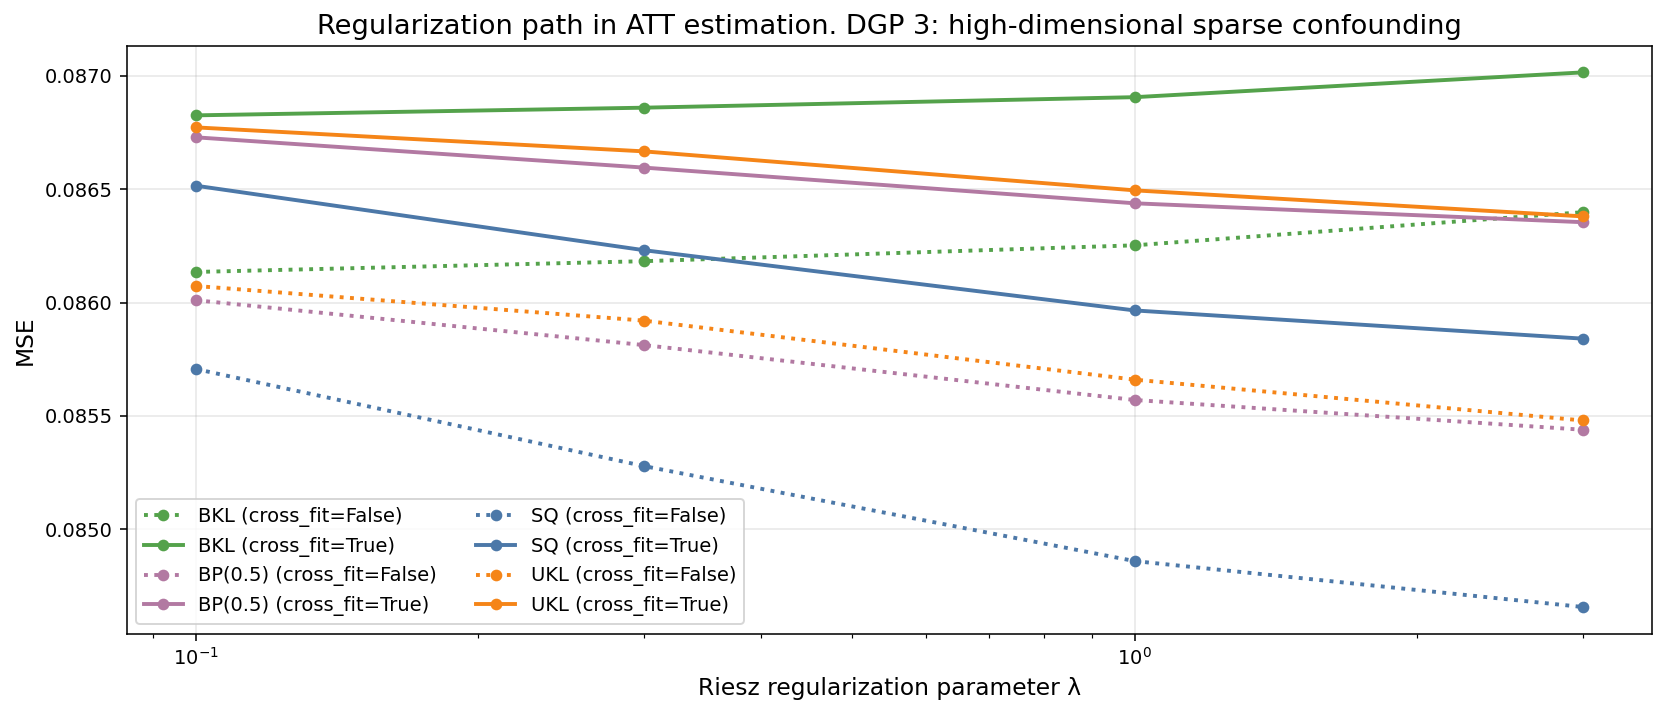

In [9]:
# MSE paths. ATE and ATT, and each DGP, are plotted separately.
plot_df = regularization_summary[regularization_summary["estimator"] == "arw"].copy()
plot_df["mse_plot"] = plot_df["mse"].clip(lower=PLOT_CONFIG["squared_error_floor"])

for estimand_name in ESTIMANDS:
    for dgp_name in DGP_NAMES:
        panel_df = plot_df[(plot_df["estimand"] == estimand_name) & (plot_df["dgp"] == dgp_name)].copy()
        if panel_df.empty:
            print(f"No path data for {estimand_name}, {dgp_name}.")
            continue
        fig, ax = plt.subplots(figsize=PLOT_CONFIG["figure_size_wide"], dpi=PLOT_CONFIG["dpi"])
        for (loss, cross_fit), g in panel_df.groupby(["loss", "cross_fit"]):
            g = g.sort_values("lambda_riesz")
            linestyle = "-" if bool(cross_fit) else ":"
            label = f"{label_of(loss)} (cross_fit={bool(cross_fit)})"
            ax.plot(g["lambda_riesz"], g["mse_plot"], marker="o", markersize=PLOT_CONFIG["marker_size"], linewidth=PLOT_CONFIG["line_width"], linestyle=linestyle, color=METHOD_COLORS.get(loss), label=label)
        ax.set_xscale("log")
        ax.set_title(f"Regularization path in {estimand_name} estimation. {dgp_name}", fontsize=PLOT_CONFIG["title_fontsize"])
        ax.set_xlabel("Riesz regularization parameter λ", fontsize=PLOT_CONFIG["axis_fontsize"])
        ax.set_ylabel("MSE", fontsize=PLOT_CONFIG["axis_fontsize"])
        ax.tick_params(axis="both", labelsize=PLOT_CONFIG["tick_fontsize"])
        ax.grid(alpha=PLOT_CONFIG["grid_alpha"])
        ax.legend(fontsize=PLOT_CONFIG["legend_fontsize"], ncol=2)
        fig.tight_layout()
        plt.show()
